<a href="https://colab.research.google.com/github/moongoldpk/Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/blob/main/Customer%20Churn%20Prediction%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
pip install pandas

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [142]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn (1).csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [144]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

In [87]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7068 entries, 0 to 7067
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [89]:
import pandas as pd
import numpy as np
import os
import glob



In [90]:
# --- Missing Data Matrix ---
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("⚠️ Missing Values Found:\n", missing)
else:
    print("✅ Zero missing values. Data is clean.")

# --- Statistical Summary of Numeric Features ---
# Note: tenure, MonthlyCharges, TotalCharges
print("\n📊 Numeric Distribution:\n", df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

# --- Check for Zero-Variance Columns (Leaks) ---
# (If a column has only 1 unique value, it's useless)
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"⚠️ Column '{col}' has zero variance - consider dropping.")

⚠️ Missing Values Found:
 customerID          25
gender              25
SeniorCitizen       25
Partner             25
Dependents          25
tenure              25
PhoneService        25
MultipleLines       25
InternetService     25
OnlineSecurity      25
OnlineBackup        25
DeviceProtection    25
TechSupport         25
StreamingTV         25
StreamingMovies     25
Contract            25
PaperlessBilling    25
PaymentMethod       25
MonthlyCharges      25
TotalCharges        25
Churn               25
dtype: int64

📊 Numeric Distribution:
             tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.761692
std      24.559481       30.090047
min       0.000000       18.250000
25%       9.000000       35.500000
50%      29.000000       70.350000
75%      55.000000       89.850000
max      72.000000      118.750000


🔴 Churn Rate: 26.54%
🟢 Retention Rate: 73.46%


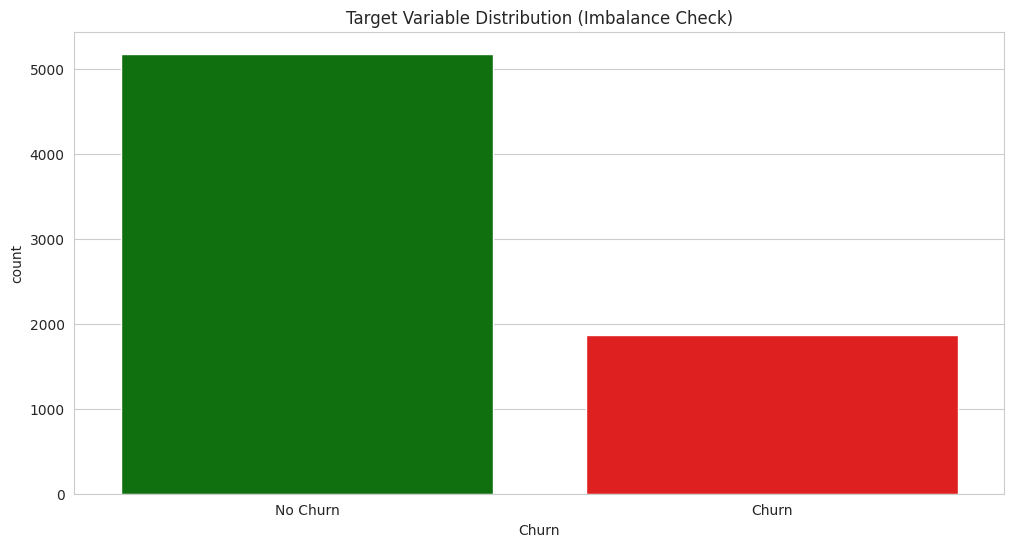

In [92]:
# --- Target Distribution ---
# df['Churn'] is numeric (0 = No, 1 = Yes)
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"🔴 Churn Rate: {churn_rate[1]:.2f}%")   # 1 = Churn
print(f"🟢 Retention Rate: {churn_rate[0]:.2f}%") # 0 = No Churn

# Visual – use numeric values but label axes
sns.countplot(x=df['Churn'], palette=['green', 'red'])
plt.title('Target Variable Distribution (Imbalance Check)')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

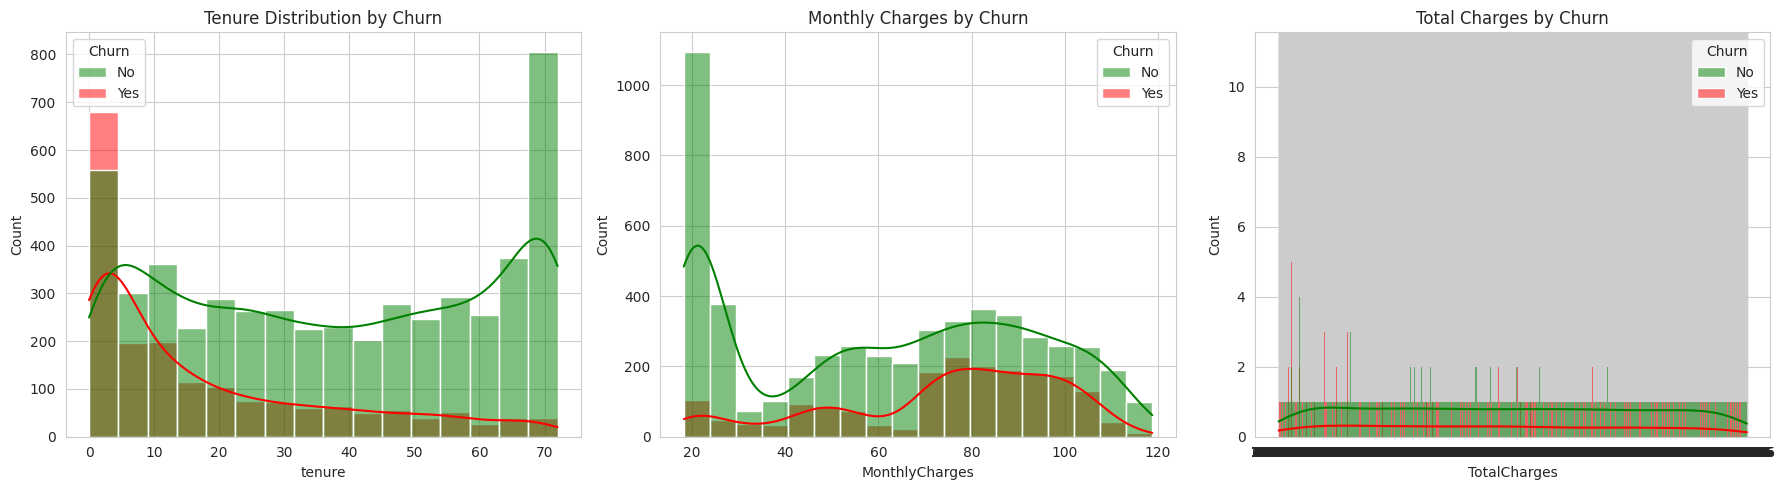

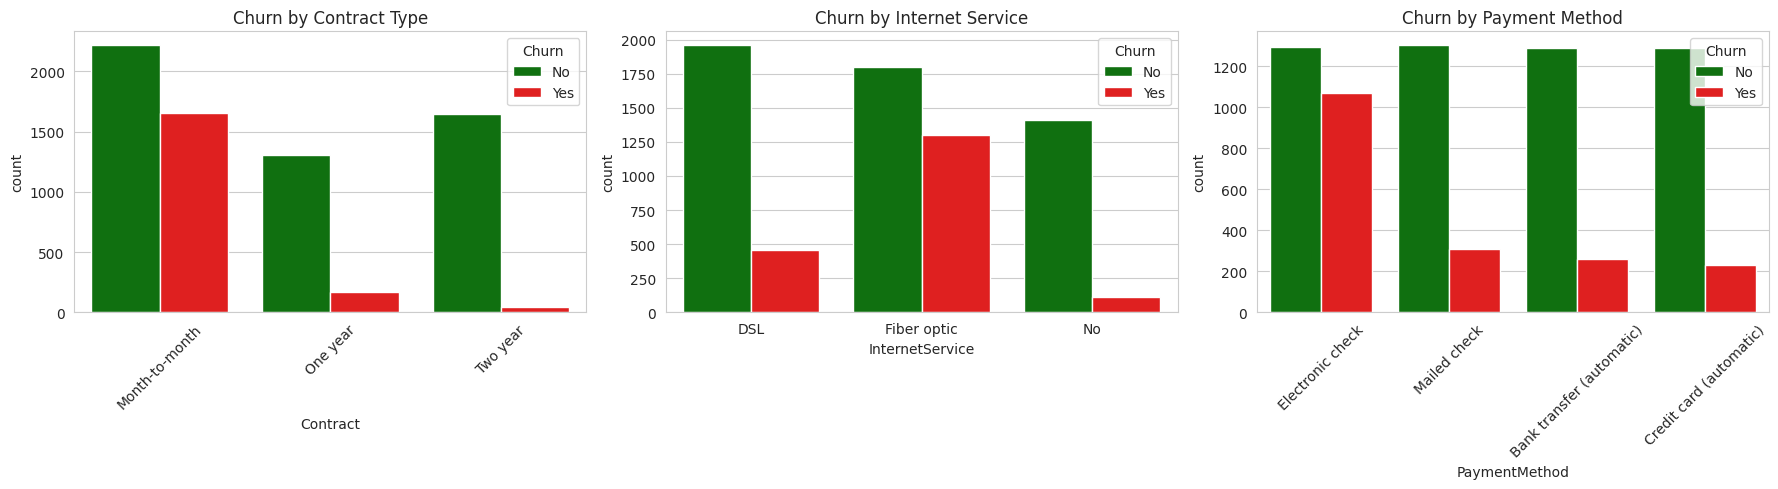

In [93]:
# 1. NUMERIC DRIVERS (Tenure & Charges)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure: Churners leave EARLY. Non-churners stay long.
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Tenure Distribution by Churn')

# Monthly Charges: Churners tend to have higher monthly bills.
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Monthly Charges by Churn')

# Total Charges: Churners have low total lifetime value.
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Total Charges by Churn')
plt.tight_layout()
plt.show()

# 2. CATEGORICAL DRIVERS (The "Big 3")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Contract: MONTH-TO-MONTH is the biggest churn red flag.
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Churn by Contract Type')
axes[0].tick_params(axis='x', rotation=45)

# Internet Service: Fiber Optic users churn more than DSL (usually due to price).
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Churn by Internet Service')

# Payment Method: Electronic check users churn drastically more.
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Churn by Payment Method')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [94]:
from scipy.stats import chi2_contingency, ttest_ind

# --- T-Test: Do Churners have significantly different Tenure? ---
churn_tenure = df[df['Churn'] == 'Yes']['tenure']
no_churn_tenure = df[df['Churn'] == 'No']['tenure']
t_stat, p_val = ttest_ind(churn_tenure, no_churn_tenure)
print(f"🔬 T-Test for Tenure (Churn vs No-Churn): P-Value = {p_val:.10f}")
print("   (If p < 0.05, the difference is statistically significant)")

# --- Chi-Square: Is Contract Type dependent on Churn? ---
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"🔬 Chi-Square for Contract vs Churn: P-Value = {p:.10f}")

🔬 T-Test for Tenure (Churn vs No-Churn): P-Value = 0.0000000000
   (If p < 0.05, the difference is statistically significant)
🔬 Chi-Square for Contract vs Churn: P-Value = 0.0000000000


Non‑numeric columns after encoding: []


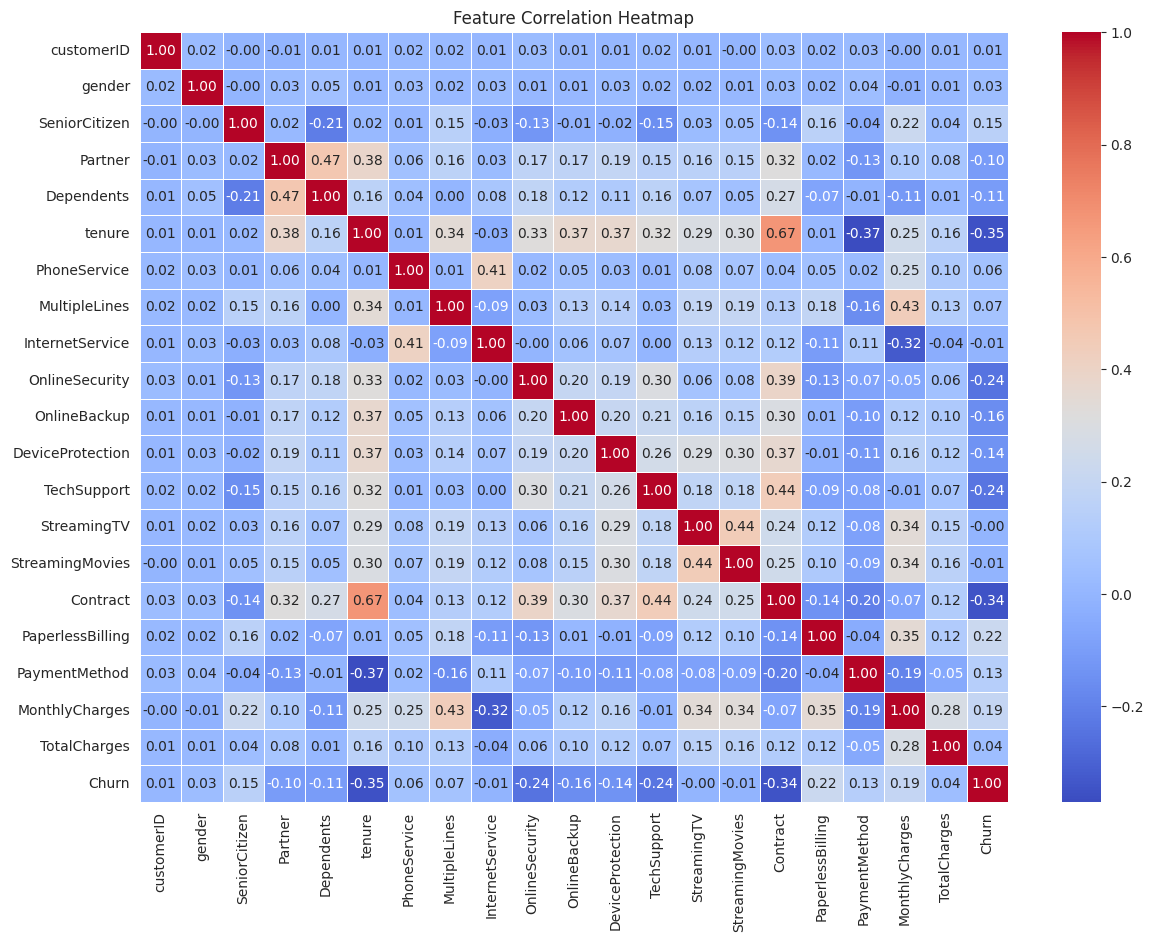

In [95]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Encode all non‑numeric columns (object and category)
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Optional: verify all columns are now numeric
print("Non‑numeric columns after encoding:", df_encoded.select_dtypes(exclude=['int64', 'float64']).columns.tolist())

plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

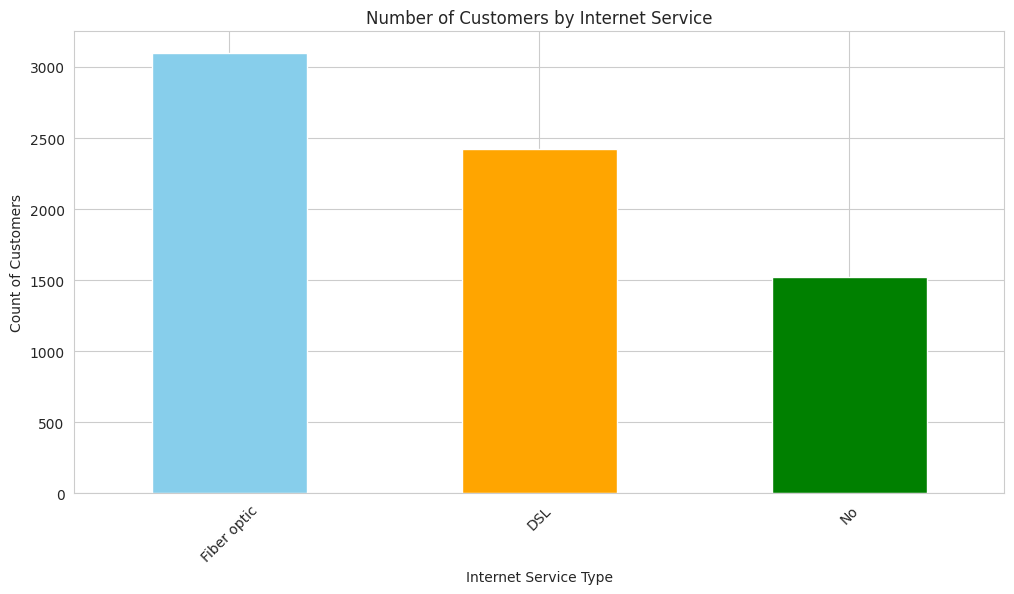

In [96]:
import matplotlib.pyplot as plt

# 1. Count how many customers are in each Internet Service group
counts = df['InternetService'].value_counts()

# 2. Plot it
counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title('Number of Customers by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Count of Customers')
plt.xticks(rotation=45)  # Prevents overlapping labels
plt.show()

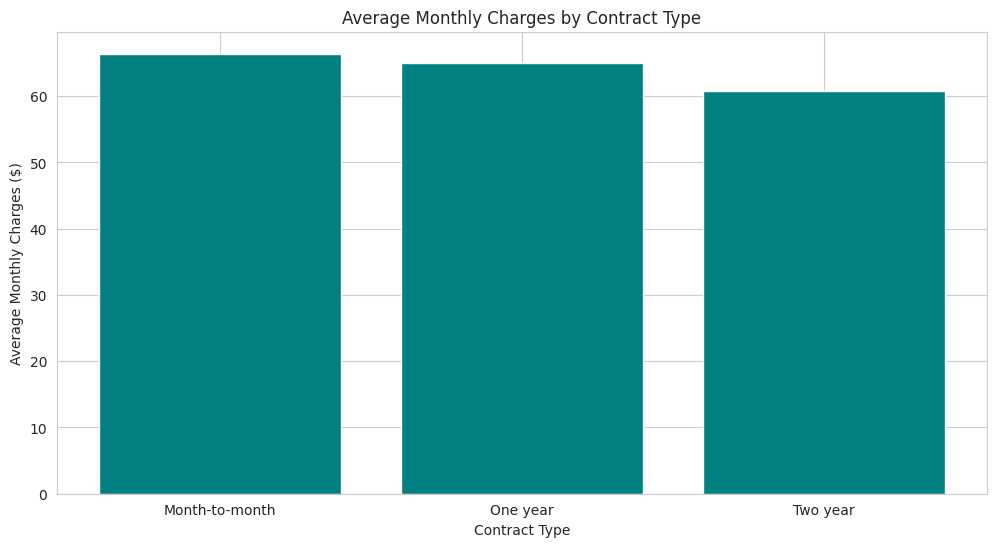

In [97]:
# 1. Group the data: Average Monthly Charge for each Contract type
aggregated = df.groupby('Contract')['MonthlyCharges'].mean().reset_index()

# 2. Plot it
plt.bar(aggregated['Contract'], aggregated['MonthlyCharges'], color='teal')
plt.title('Average Monthly Charges by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Average Monthly Charges ($)')
plt.show()

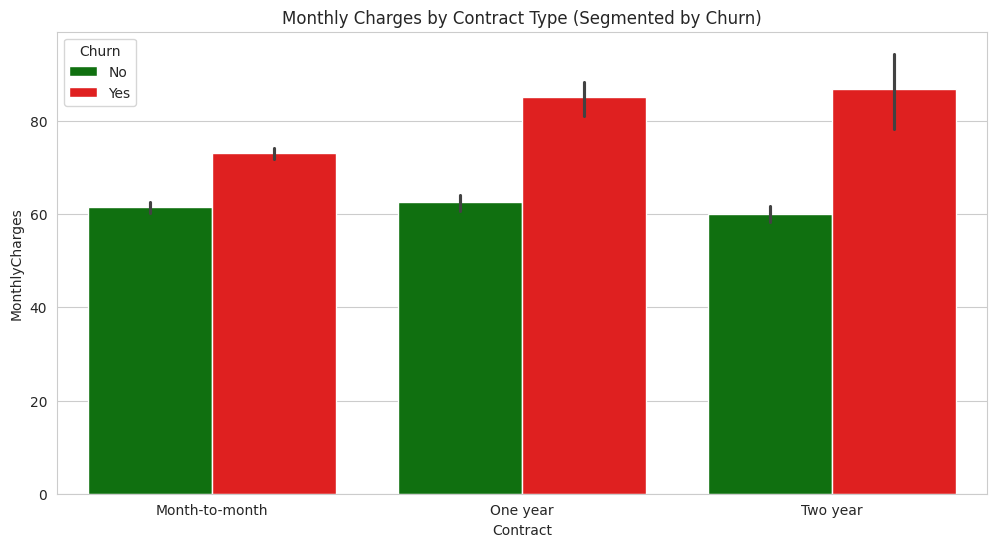

In [98]:
import seaborn as sns

# Seaborn does the grouping automatically
sns.barplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', palette=['green', 'red'])
plt.title('Monthly Charges by Contract Type (Segmented by Churn)')
plt.show()

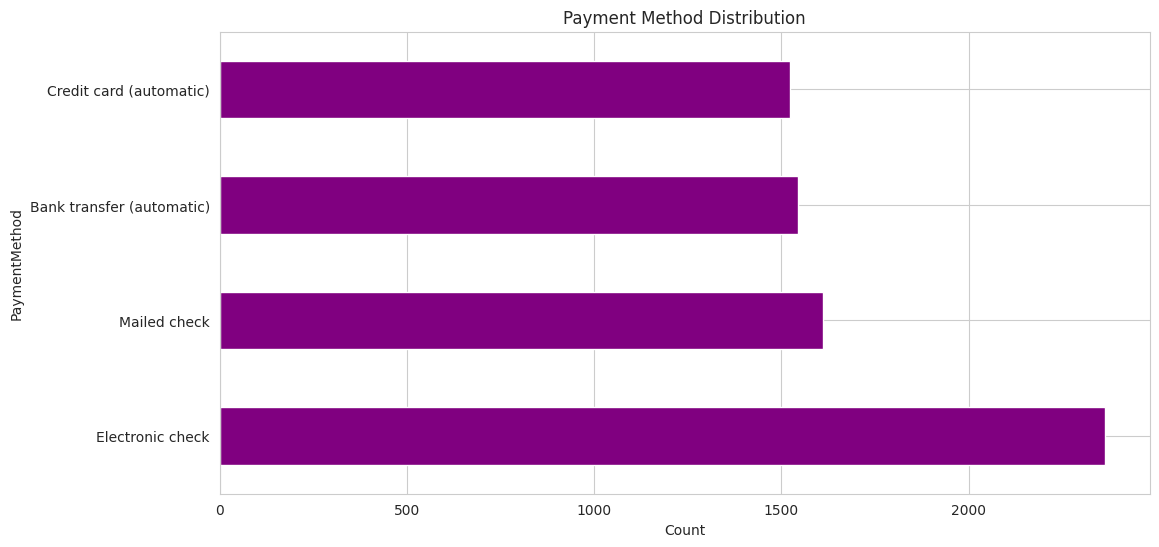

In [99]:
df['PaymentMethod'].value_counts().plot(kind='barh', color='purple')
plt.title('Payment Method Distribution')
plt.xlabel('Count')
plt.show()

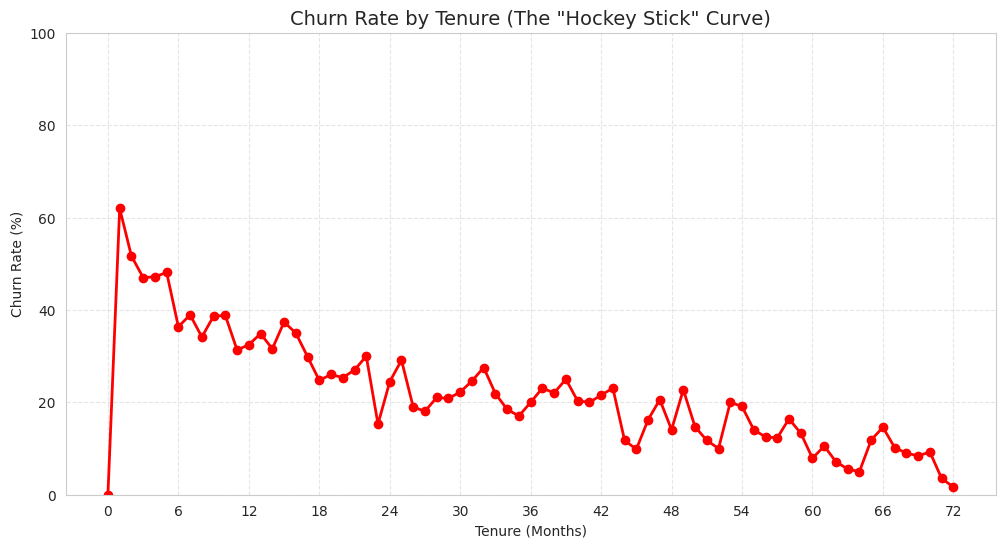

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate Churn Rate for each Tenure month (0 to 72)
churn_by_tenure = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

# 2. Plot the line
plt.figure(figsize=(12, 6))
plt.plot(churn_by_tenure.index, churn_by_tenure.values, marker='o', linestyle='-', color='red', linewidth=2)

# 3. Polish it
plt.title('Churn Rate by Tenure (The "Hockey Stick" Curve)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 73, 6))  # Show every 6 months
plt.ylim(0, 100)
plt.show()

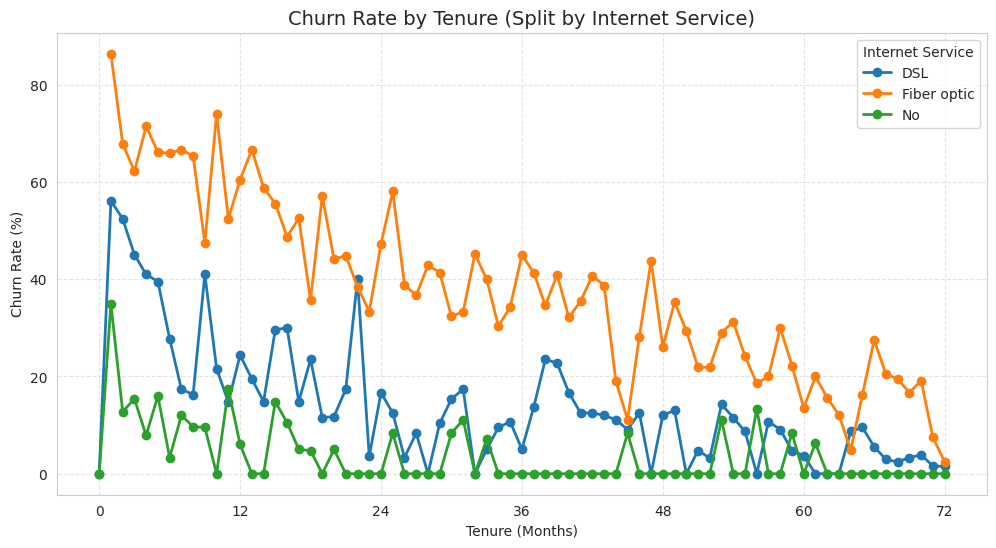

In [101]:
# 1. Group by both Tenure AND InternetService
churn_by_tenure_internet = df.groupby(['tenure', 'InternetService'])['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).unstack()

# 2. Plot multiple lines
plt.figure(figsize=(12, 6))
for service in churn_by_tenure_internet.columns:
    plt.plot(churn_by_tenure_internet.index, churn_by_tenure_internet[service],
             marker='o', label=service, linewidth=2)

plt.title('Churn Rate by Tenure (Split by Internet Service)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Internet Service')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 73, 12))  # Show every 12 months
plt.show()

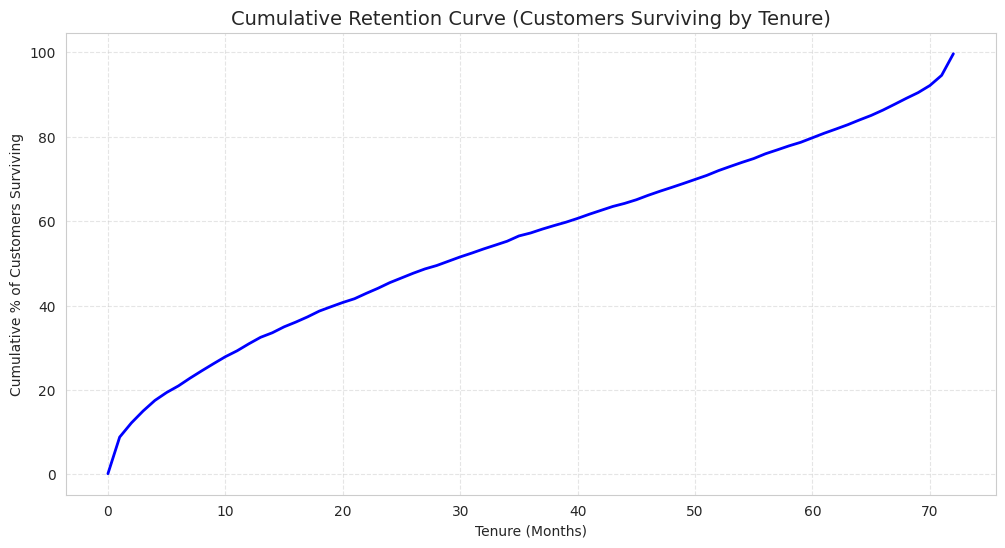

In [102]:
# 1. Count total customers who stayed at least X months
retention_curve = df.groupby('tenure').size().cumsum() / len(df) * 100

plt.figure(figsize=(12, 6))
plt.plot(retention_curve.index, retention_curve.values, color='blue', linewidth=2)
plt.title('Cumulative Retention Curve (Customers Surviving by Tenure)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Cumulative % of Customers Surviving')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

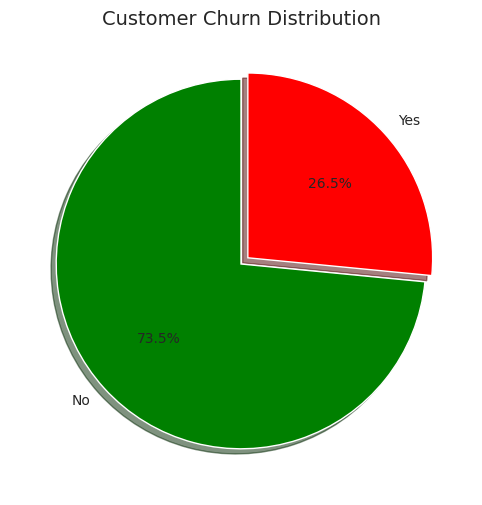

In [103]:
import matplotlib.pyplot as plt

# Plot the Churn distribution
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',  # Shows the percentage
    colors=['green', 'red'],
    explode=[0, 0.05],  # Slightly "explode" the 'Yes' slice to highlight it
    startangle=90,
    shadow=True
)

plt.title('Customer Churn Distribution', fontsize=14)
plt.ylabel('')  # Removes the default "Churn" y-label for cleanliness
plt.show()

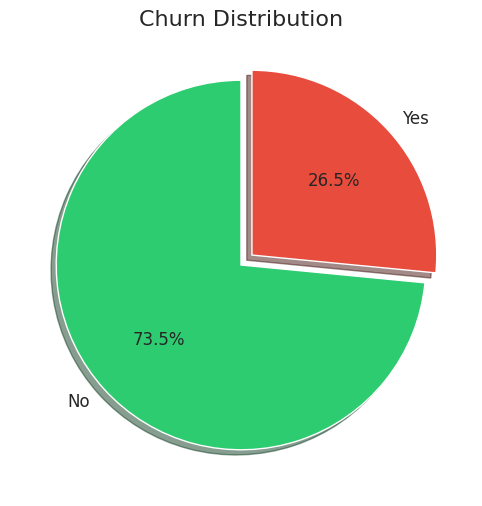

In [104]:
# 1. Prepare the data
labels = df['Churn'].value_counts().index
sizes = df['Churn'].value_counts().values
colors = ['#2ecc71', '#e74c3c']  # Professional green & red
explode = (0, 0.08)  # Explode the 2nd slice (Churners)

# 2. Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes,
       explode=explode,
       labels=labels,
       colors=colors,
       autopct='%1.1f%%',
       shadow=True,
       startangle=90,
       textprops={'fontsize': 12})

ax.set_title('Churn Distribution', fontsize=16)
plt.show()

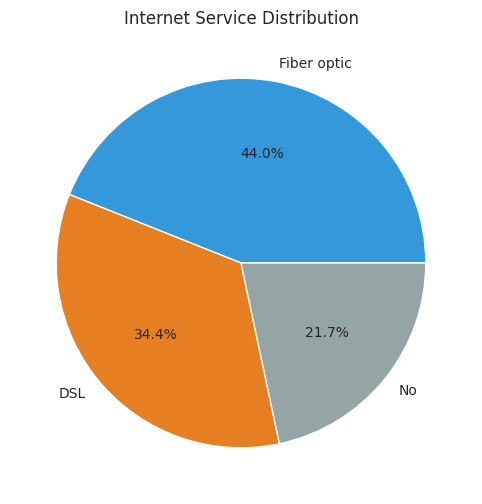

In [105]:
# Filter out 'No internet service' if you want, or keep it as-is.
df['InternetService'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#3498db', '#e67e22', '#95a5a6']
)
plt.title('Internet Service Distribution')
plt.ylabel('')
plt.show()

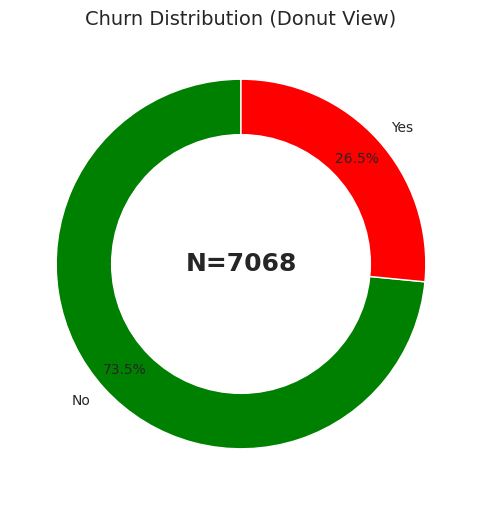

In [106]:
# Donut chart = Pie chart with a white circle in the middle
fig, ax = plt.subplots(figsize=(8, 6))

# Create the pie
wedges, texts, autotexts = ax.pie(
    df['Churn'].value_counts().values,
    labels=df['Churn'].value_counts().index,
    autopct='%1.1f%%',
    colors=['green', 'red'],
    startangle=90,
    pctdistance=0.85  # Pushes percentages outward
)

# Draw a white circle in the center
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total N in the middle
ax.text(0, 0, f'N={len(df)}', ha='center', va='center', fontsize=18, fontweight='bold')

plt.title('Churn Distribution (Donut View)', fontsize=14)
plt.show()

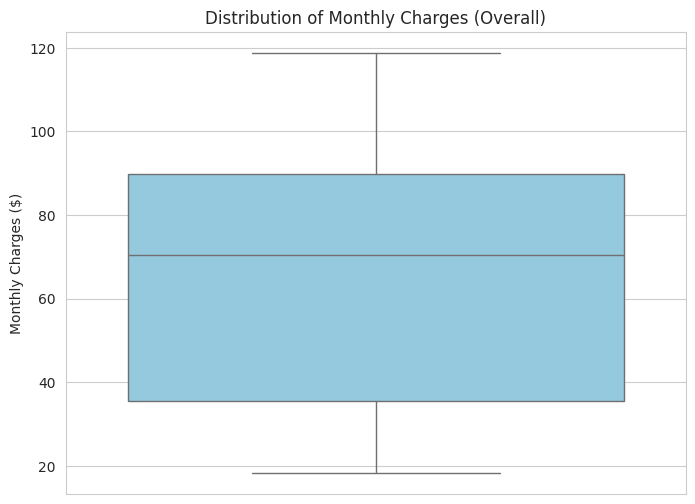

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['MonthlyCharges'], color='skyblue')
plt.title('Distribution of Monthly Charges (Overall)')
plt.ylabel('Monthly Charges ($)')
plt.show()

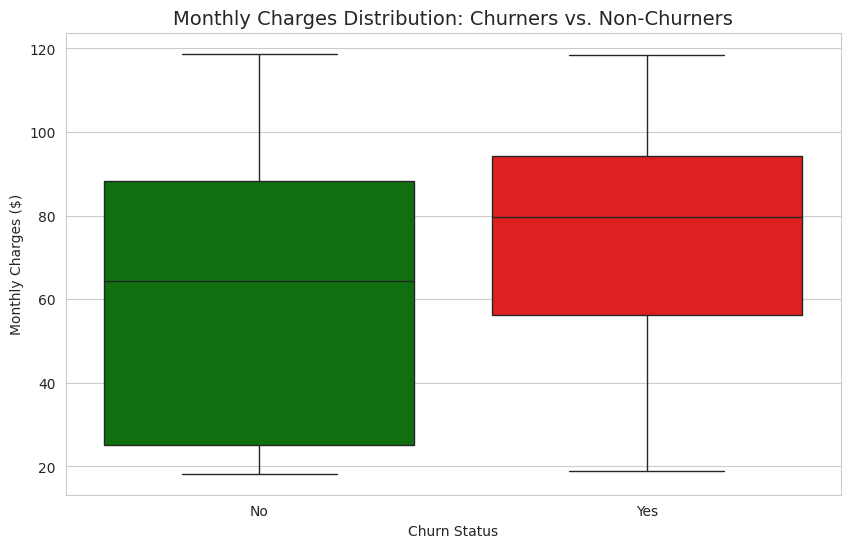

In [108]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['green', 'red'])
plt.title('Monthly Charges Distribution: Churners vs. Non-Churners', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.show()

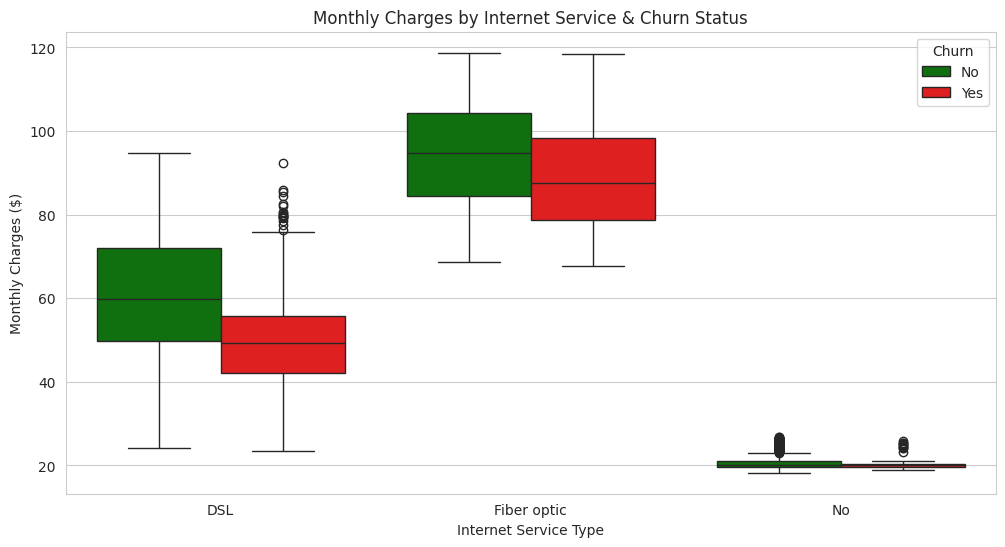

In [109]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='InternetService', y='MonthlyCharges', hue='Churn', data=df, palette=['green', 'red'])
plt.title('Monthly Charges by Internet Service & Churn Status')
plt.xlabel('Internet Service Type')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Churn')
plt.show()

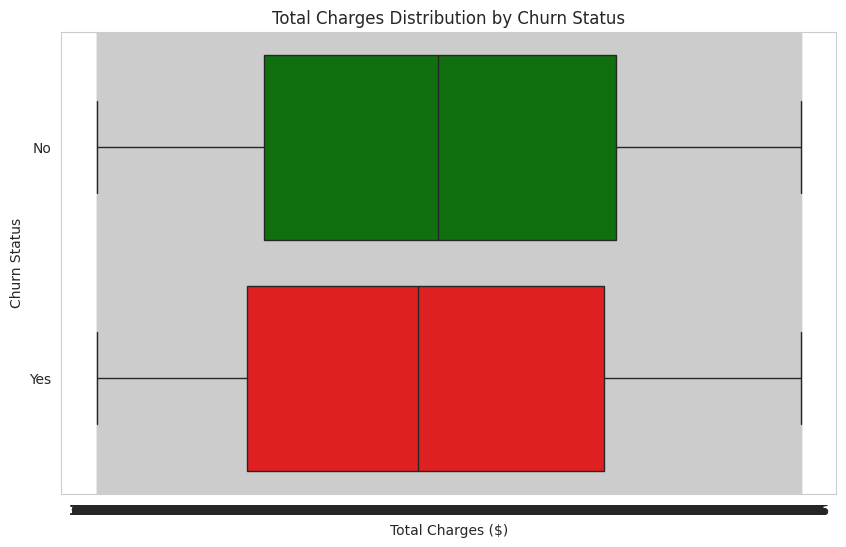

In [110]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='TotalCharges', y='Churn', data=df, palette=['green', 'red'], orient='h')
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Total Charges ($)')
plt.ylabel('Churn Status')
plt.show()

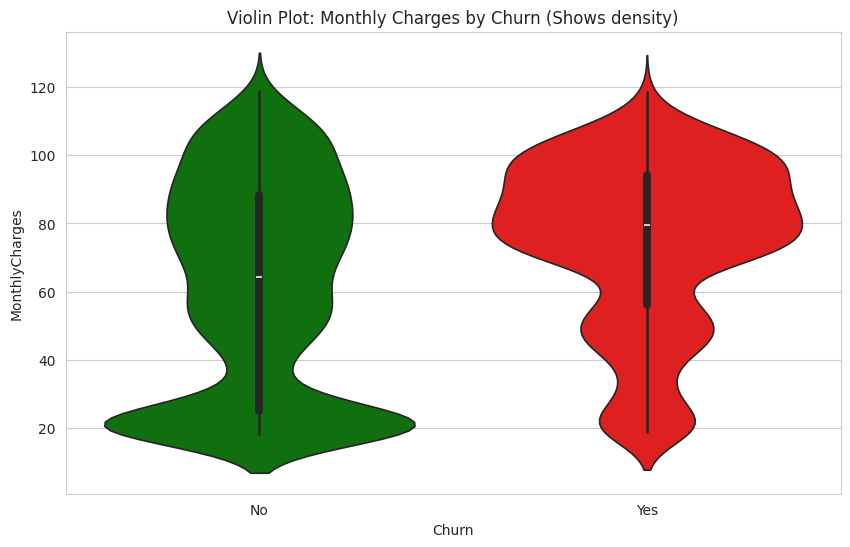

In [111]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette=['green', 'red'])
plt.title('Violin Plot: Monthly Charges by Churn (Shows density)')
plt.show()

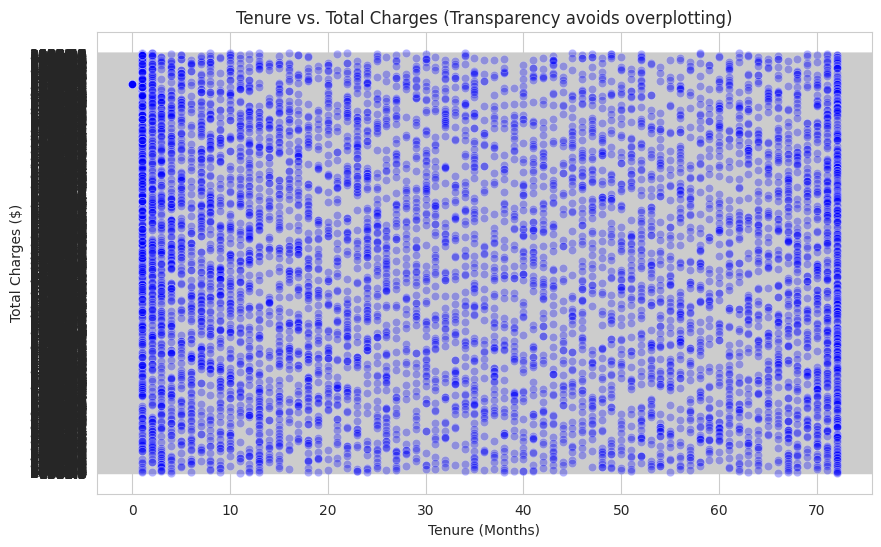

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', alpha=0.3, color='blue')
plt.title('Tenure vs. Total Charges (Transparency avoids overplotting)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges ($)')
plt.show()

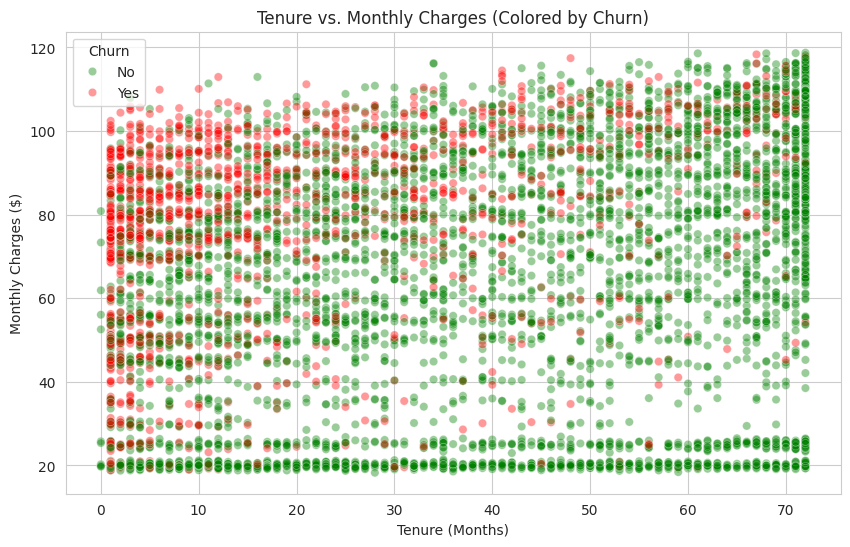

In [113]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4, palette=['green', 'red'])
plt.title('Tenure vs. Monthly Charges (Colored by Churn)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Churn')
plt.show()

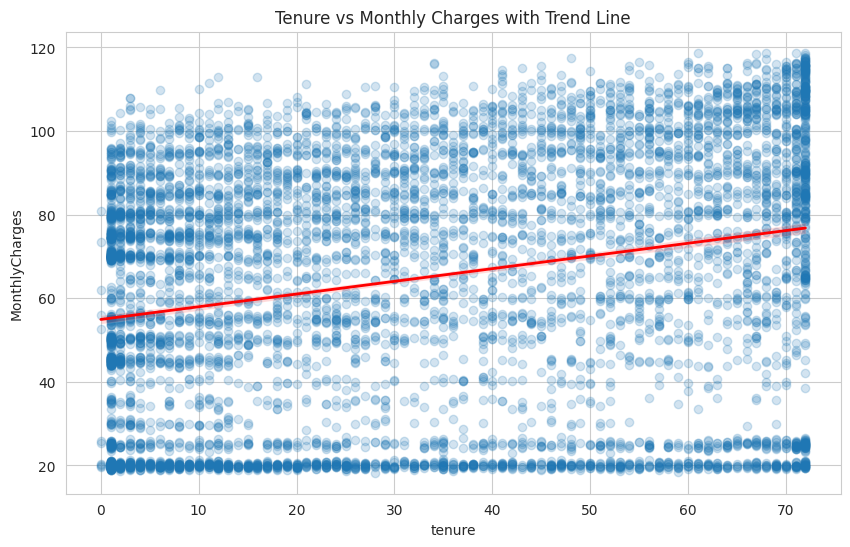

In [114]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='tenure', y='MonthlyCharges', scatter_kws={'alpha':0.2}, line_kws={'color':'red', 'linewidth':2})
plt.title('Tenure vs Monthly Charges with Trend Line')
plt.show()

In [116]:
# Convert the three columns to numeric (coerce errors to NaN)
df[['tenure', 'MonthlyCharges', 'TotalCharges']] = df[['tenure', 'MonthlyCharges', 'TotalCharges']].apply(pd.to_numeric, errors='coerce')

# Drop any rows with missing values in these columns (just to be safe)
df = df.dropna(subset=['tenure', 'MonthlyCharges', 'TotalCharges'])

# Verify dtypes
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)

tenure            float64
MonthlyCharges    float64
TotalCharges      float64
dtype: object


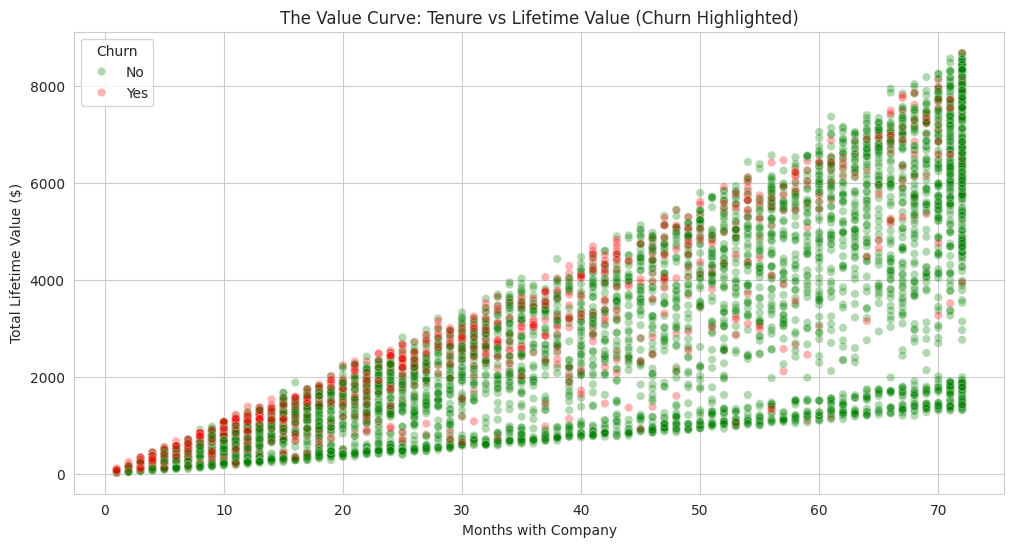

In [117]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.3, palette=['green', 'red'])
plt.title('The Value Curve: Tenure vs Lifetime Value (Churn Highlighted)')
plt.xlabel('Months with Company')
plt.ylabel('Total Lifetime Value ($)')
plt.legend(title='Churn')
plt.show()

In [118]:
# Returns a tuple: (Number of Rows, Number of Columns)
print(df.shape)

(7032, 21)


In [119]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# First 5 rows
print(df.head())

# Last 5 rows
print(df.tail())

# 10 completely random rows (great for spotting weird edge cases)
print(df.sample(10))

In [120]:
# Count how many times 'Yes' appears in the Churn column
churn_count = df['Churn'].value_counts()
print(churn_count)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [121]:
print(f"Total rows loaded: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Rows with all null: {df.isnull().all(axis=1).sum()}")
print(df.tail(10))

Total rows loaded: 7032
Duplicate rows: 0
Rows with all null: 0
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7033  9767-FFLEM    Male            0.0      No         No    38.0   
7034  0639-TSIQW  Female            0.0      No         No    67.0   
7035  8456-QDAVC    Male            0.0      No         No    19.0   
7036  7750-EYXWZ  Female            0.0      No         No    12.0   
7037  2569-WGERO  Female            0.0      No         No    72.0   
7038  6840-RESVB    Male            0.0     Yes        Yes    24.0   
7039  2234-XADUH  Female            0.0     Yes        Yes    72.0   
7040  4801-JZAZL  Female            0.0     Yes        Yes    11.0   
7041  8361-LTMKD    Male            1.0     Yes         No     4.0   
7042  3186-AJIEK    Male            0.0      No         No    66.0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
7033          Yes                No     Fiber optic                   No  ...   
703

In [125]:
# 1. Look at the LAST 10 rows. The culprits are almost always at the bottom.
print("🔍 Last 10 rows of the dataset:")
print(df.tail(10))

# 2. Count exact duplicate rows (identical across all columns)
print(f"\n📊 Exact duplicate rows: {df.duplicated().sum()}")

# 3. Count rows where every single cell is empty (blank line artifacts)
print(f"📊 Completely empty rows: {df.isnull().all(axis=1).sum()}")

# 4. Check for 'customerID' if you accidentally kept it, or check the index
print(f"\n📊 Total physical rows: {len(df)}")

🔍 Last 10 rows of the dataset:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7033  9767-FFLEM    Male            0.0      No         No    38.0   
7034  0639-TSIQW  Female            0.0      No         No    67.0   
7035  8456-QDAVC    Male            0.0      No         No    19.0   
7036  7750-EYXWZ  Female            0.0      No         No    12.0   
7037  2569-WGERO  Female            0.0      No         No    72.0   
7038  6840-RESVB    Male            0.0     Yes        Yes    24.0   
7039  2234-XADUH  Female            0.0     Yes        Yes    72.0   
7040  4801-JZAZL  Female            0.0     Yes        Yes    11.0   
7041  8361-LTMKD    Male            1.0     Yes         No     4.0   
7042  3186-AJIEK    Male            0.0      No         No    66.0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
7033          Yes                No     Fiber optic                   No  ...   
7034          Yes               Yes 

In [128]:
# Check total customers
print(f"Total Customers: {len(df)}")

# Check Churn Split
print(df['Churn'].value_counts())

# Check the 11 customers who had missing TotalCharges (now filled with 0)
print(df[df['tenure'] == 0][['customerID', 'tenure', 'TotalCharges']].head())

Total Customers: 7032
Churn
No     5163
Yes    1869
Name: count, dtype: int64
Empty DataFrame
Columns: [customerID, tenure, TotalCharges]
Index: []


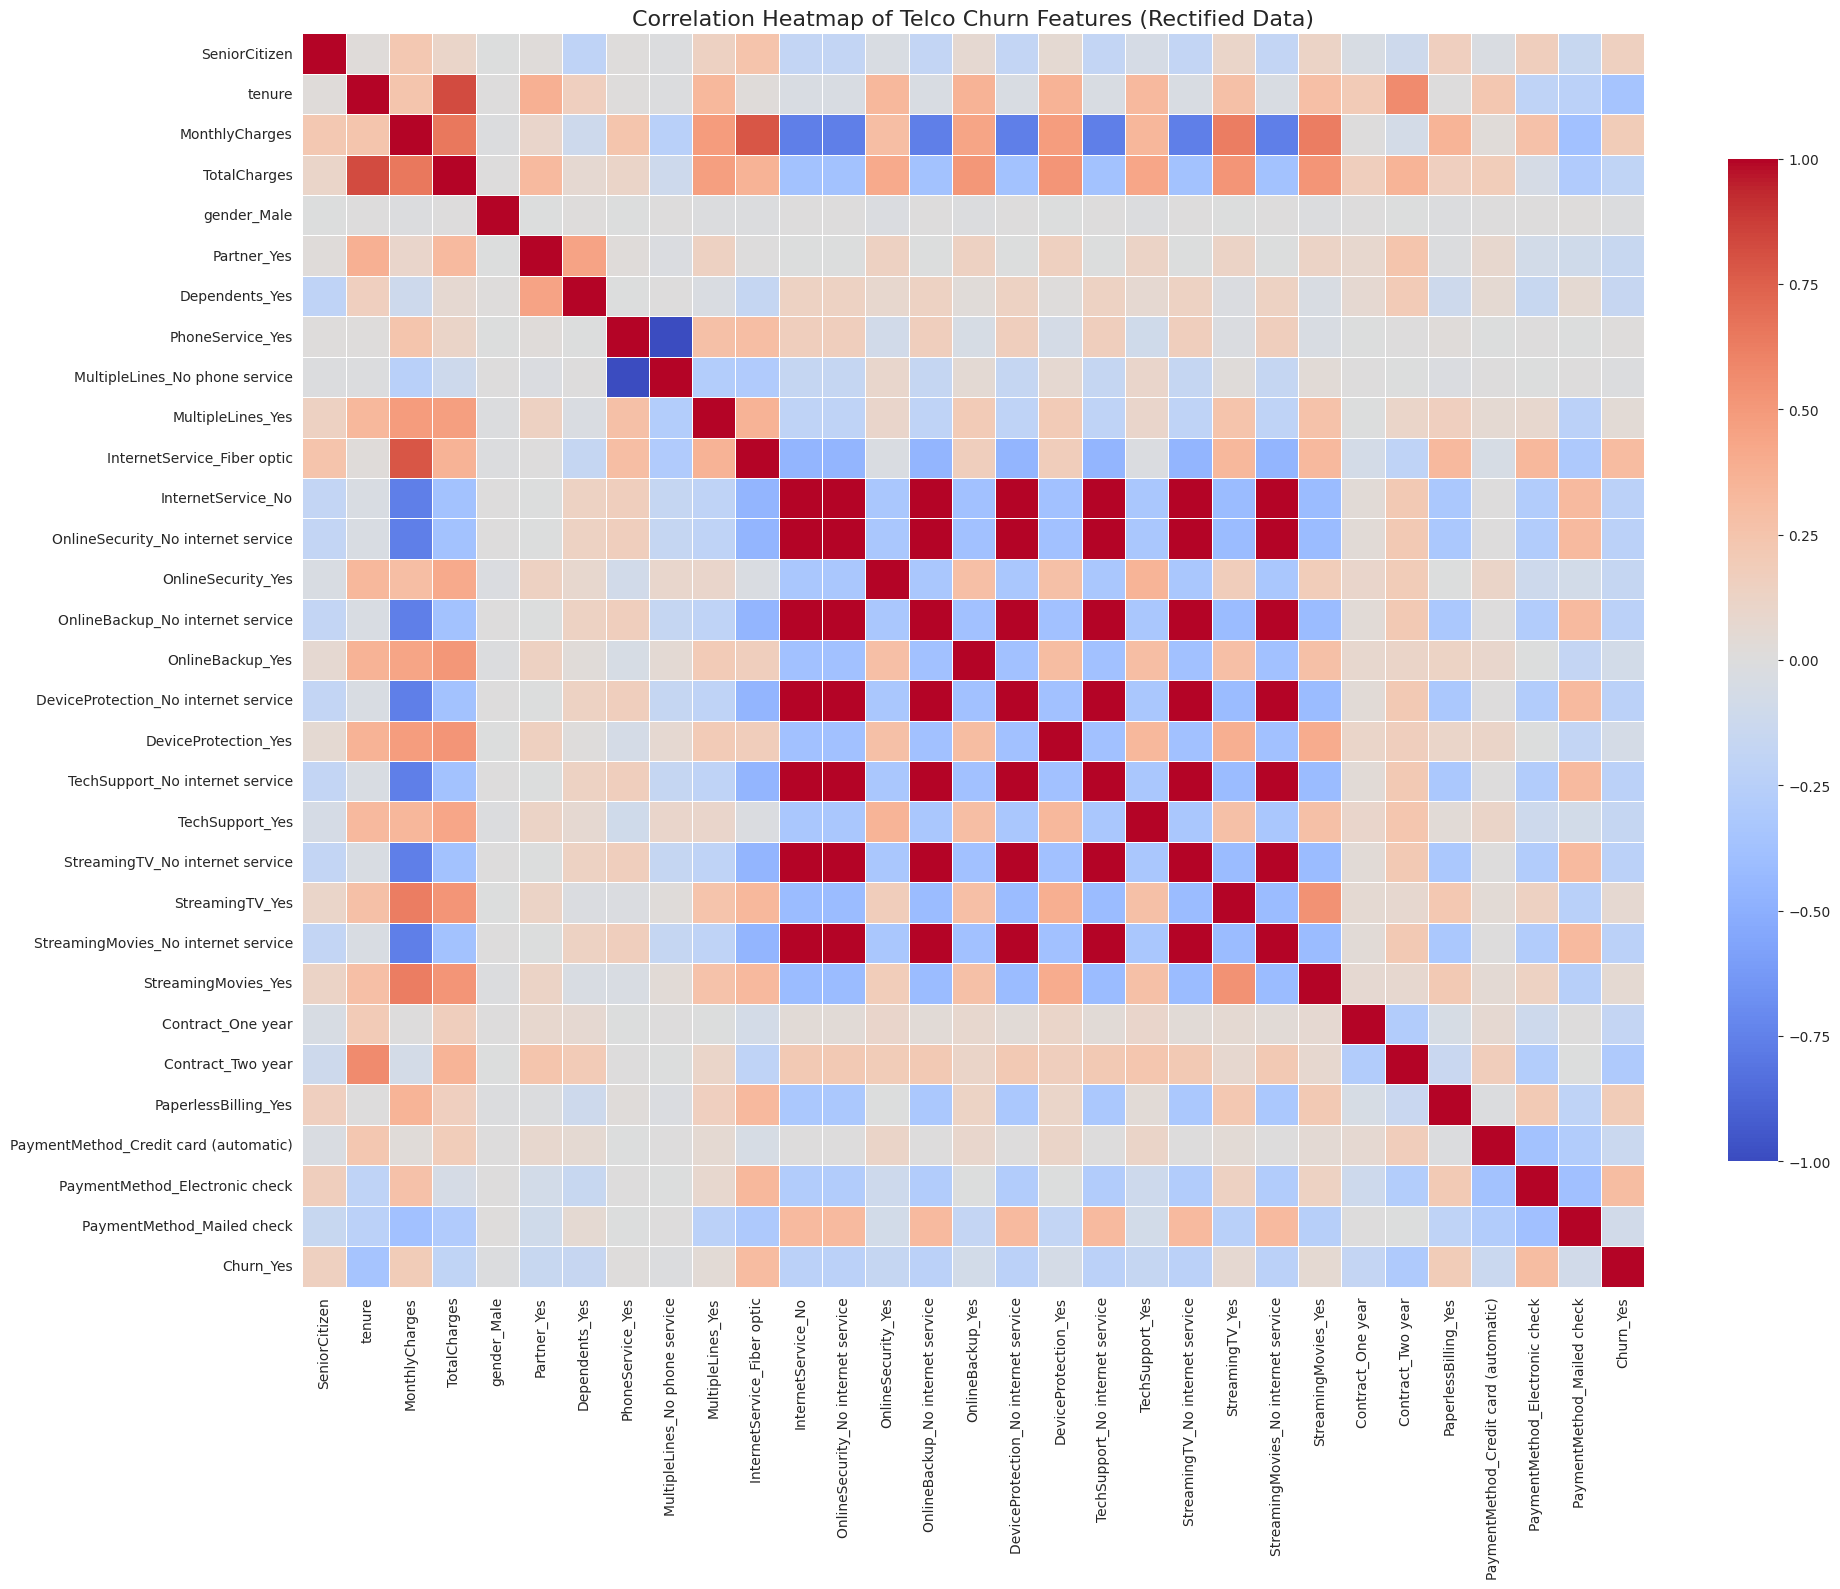


🔍 Top 10 Features Correlated with Churn (Positive = More Churn):
Churn_Yes                         1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService_Yes                  0.011691
Name: Churn_Yes, dtype: float64

🔍 Bottom 10 Features Correlated with Churn (Negative = Less Churn):
TotalCharges                           -0.199484
OnlineSecurity_No internet service     -0.227578
StreamingMovies_No internet service    -0.227578
OnlineBackup_No internet service       -0.227578
InternetService_No                     -0.227578
TechSupport_No internet service        -0.227578
DeviceProtection_No internet service   -0.227578
StreamingTV_No internet service        -0.227578
Contract_Tw

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Drop customerID (not a feature)
df_corr = df.drop('customerID', axis=1)

# Separate numeric and categorical columns
num_cols = df_corr.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_corr.select_dtypes(include=['object']).columns

# Create dummies for categorical columns
df_encoded = pd.get_dummies(df_corr, columns=cat_cols, drop_first=True)

# Compute correlation matrix
corr_matrix = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Telco Churn Features (Rectified Data)', fontsize=16)
plt.tight_layout()
plt.show()

# Print top correlations with Churn_Yes
churn_corr = corr_matrix['Churn_Yes'].sort_values(ascending=False)
print("\n🔍 Top 10 Features Correlated with Churn (Positive = More Churn):")
print(churn_corr.head(10))
print("\n🔍 Bottom 10 Features Correlated with Churn (Negative = Less Churn):")
print(churn_corr.tail(10))

📊 Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
📊 Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


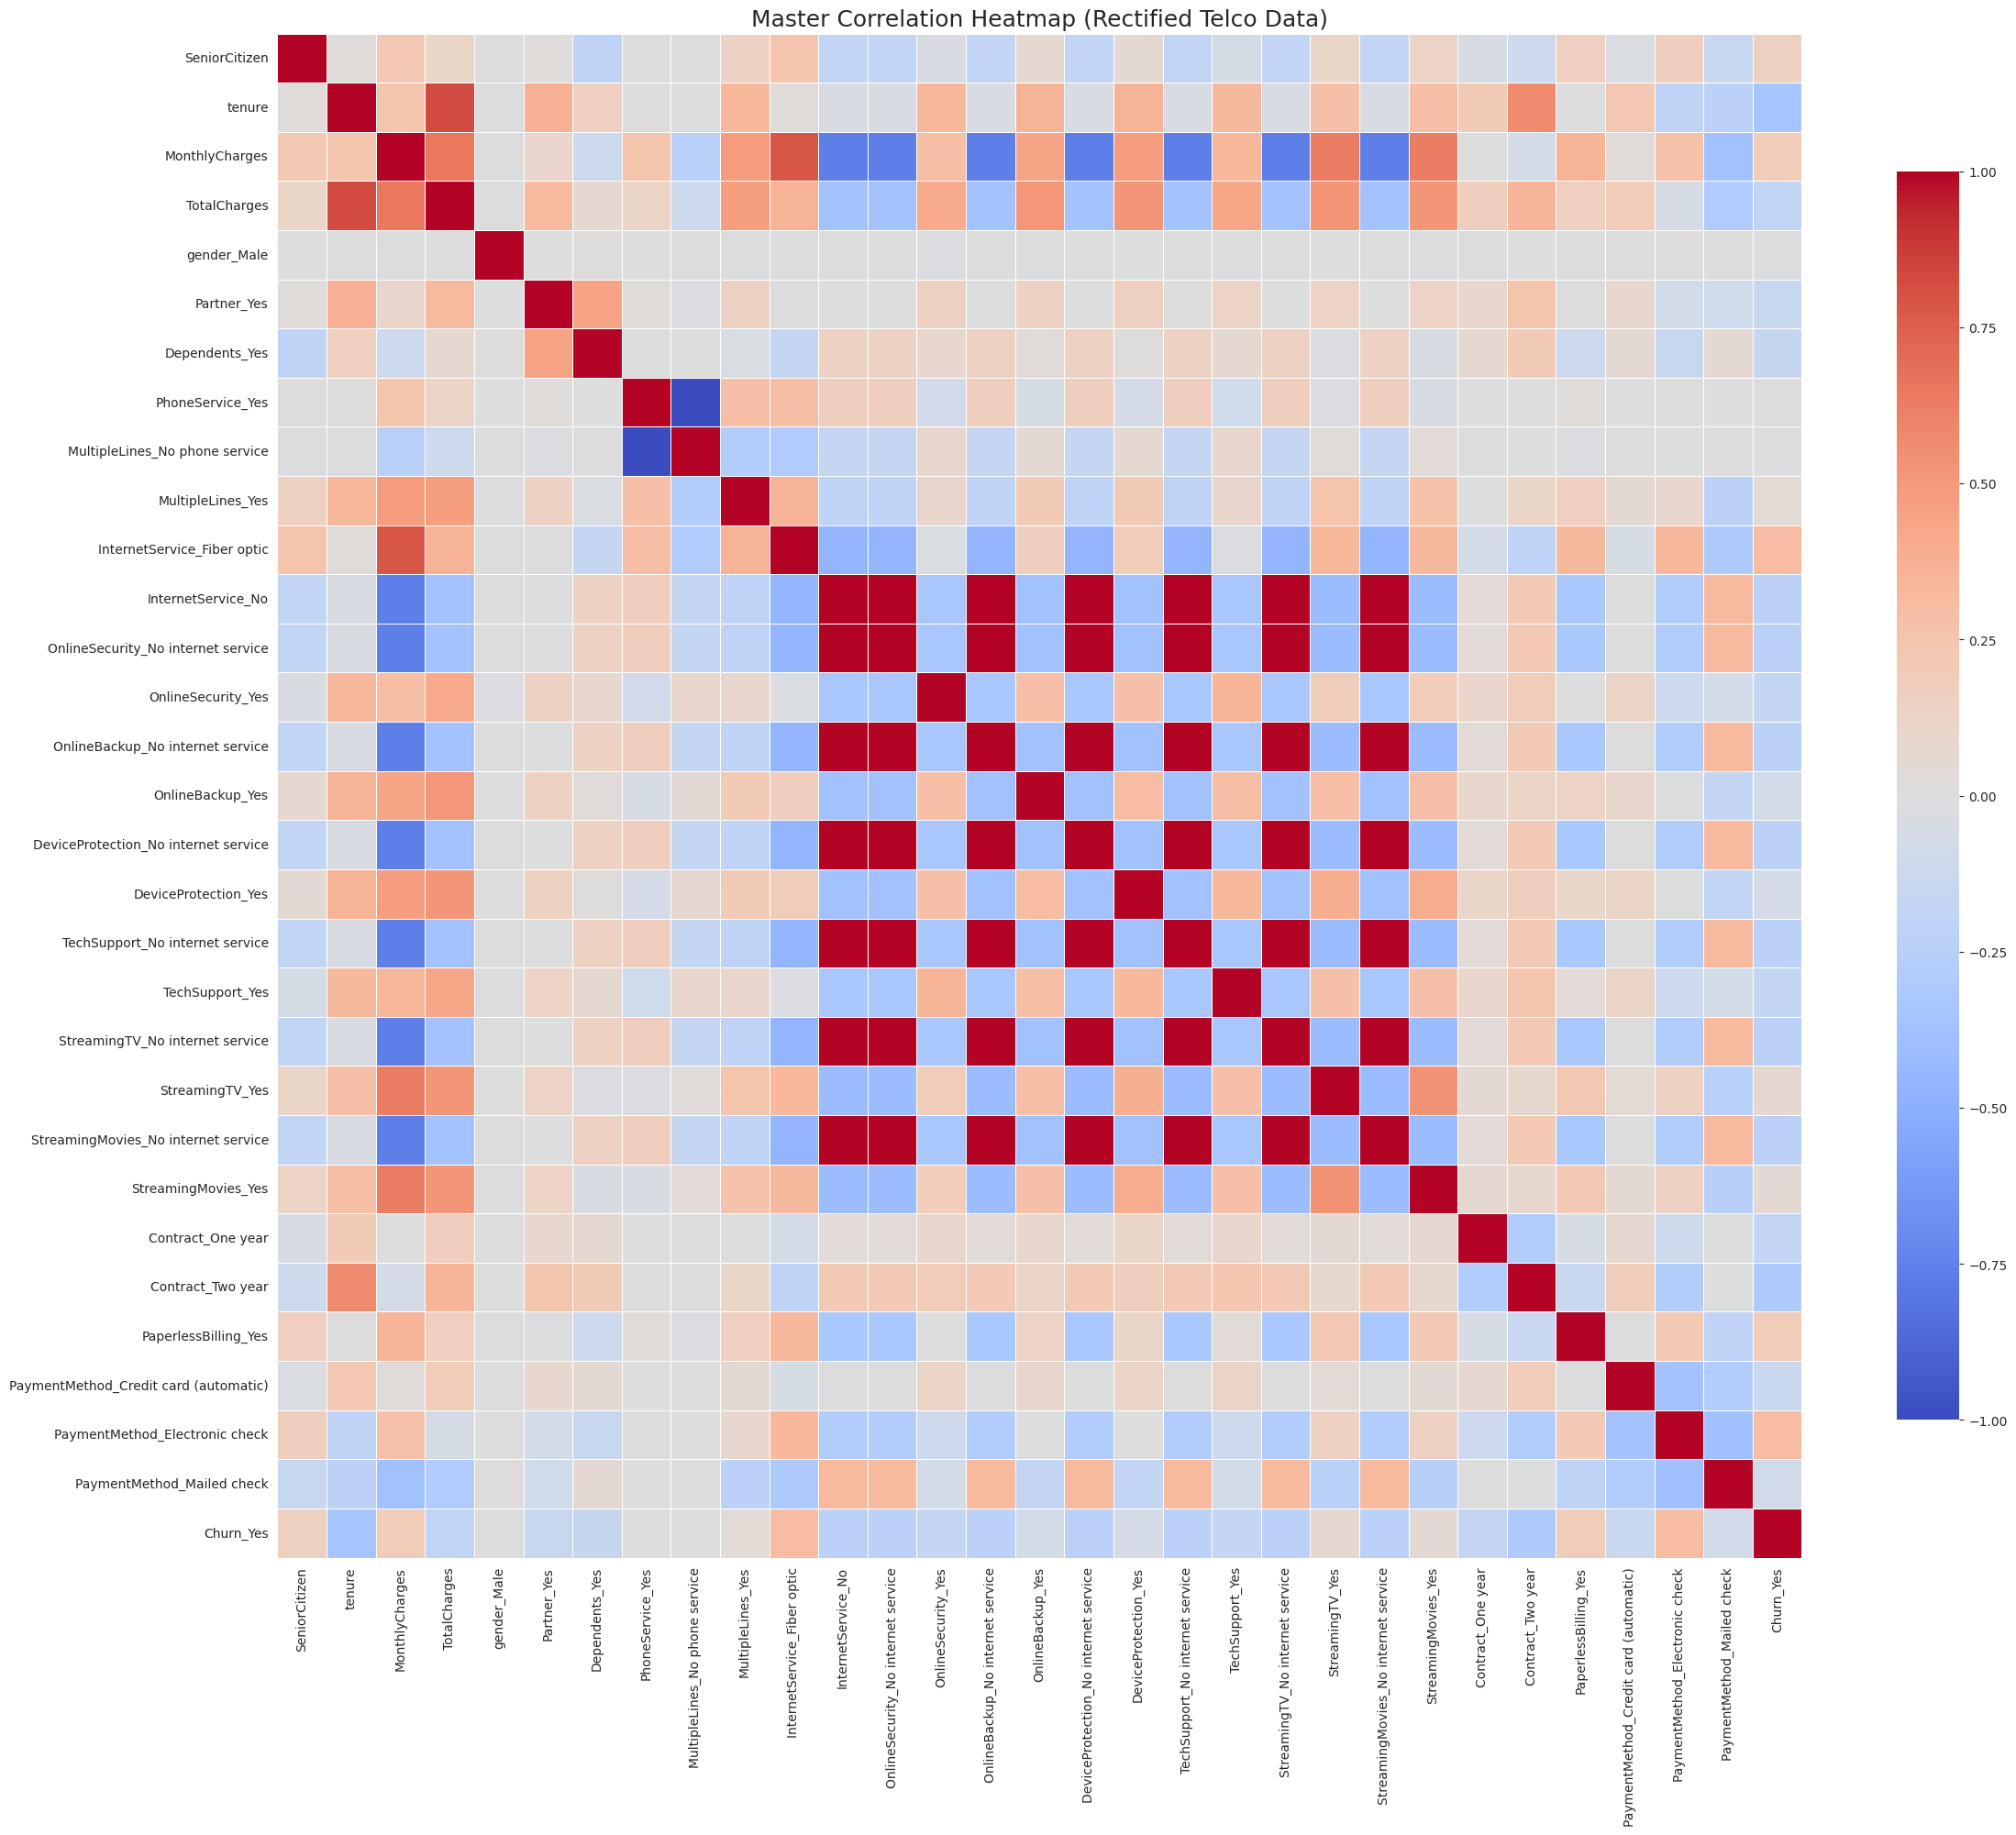


🎯 TOP 5 DRIVERS THAT INCREASE CHURN (Positive Correlation)
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
Name: Churn_Yes, dtype: float64

🛡️ TOP 5 DRIVERS THAT DECREASE CHURN (Negative Correlation)
tenure                               -0.354049
Contract_Two year                    -0.301552
OnlineSecurity_No internet service   -0.227578
OnlineBackup_No internet service     -0.227578
TechSupport_No internet service      -0.227578
Name: Churn_Yes, dtype: float64


In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set professional aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- 1. Drop the unnecessary ID column (useless for correlation) ---
df_corr = df.drop('customerID', axis=1)

# --- 2. Separate numeric and categorical columns ---
num_cols = df_corr.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_corr.select_dtypes(include=['object']).columns

print(f"📊 Numeric features: {list(num_cols)}")
print(f"📊 Categorical features: {list(cat_cols)}")

# --- 3. Encode categorical variables (One-Hot Encoding) ---
# This creates binary 0/1 columns for categories like 'DSL', 'Fiber optic', etc.
df_encoded = pd.get_dummies(df_corr, columns=cat_cols, drop_first=True)

# --- 4. Compute the Correlation Matrix ---
corr_matrix = df_encoded.corr()

# --- 5. Plot the Master Heatmap ---
plt.figure(figsize=(24, 20))  # Large canvas to see all features
sns.heatmap(
    corr_matrix,
    annot=False,              # Turn off annotations to avoid clutter (we'll print the top ones)
    cmap='coolwarm',          # Red = Positive, Blue = Negative
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    square=True
)
plt.title('Master Correlation Heatmap (Rectified Telco Data)', fontsize=18)
plt.tight_layout()
plt.show()

# --- 6. The "Executive Summary" Printout (Most Important) ---
# Grab the correlations with our target 'Churn_Yes'
# (Note: 'Churn_Yes' exists because we one-hot encoded the 'Churn' column)
churn_corr = corr_matrix['Churn_Yes'].drop('Churn_Yes').sort_values()

print("\n" + "="*60)
print("🎯 TOP 5 DRIVERS THAT INCREASE CHURN (Positive Correlation)")
print("="*60)
print(churn_corr.tail(5).sort_values(ascending=False))

print("\n" + "="*60)
print("🛡️ TOP 5 DRIVERS THAT DECREASE CHURN (Negative Correlation)")
print("="*60)
print(churn_corr.head(5))

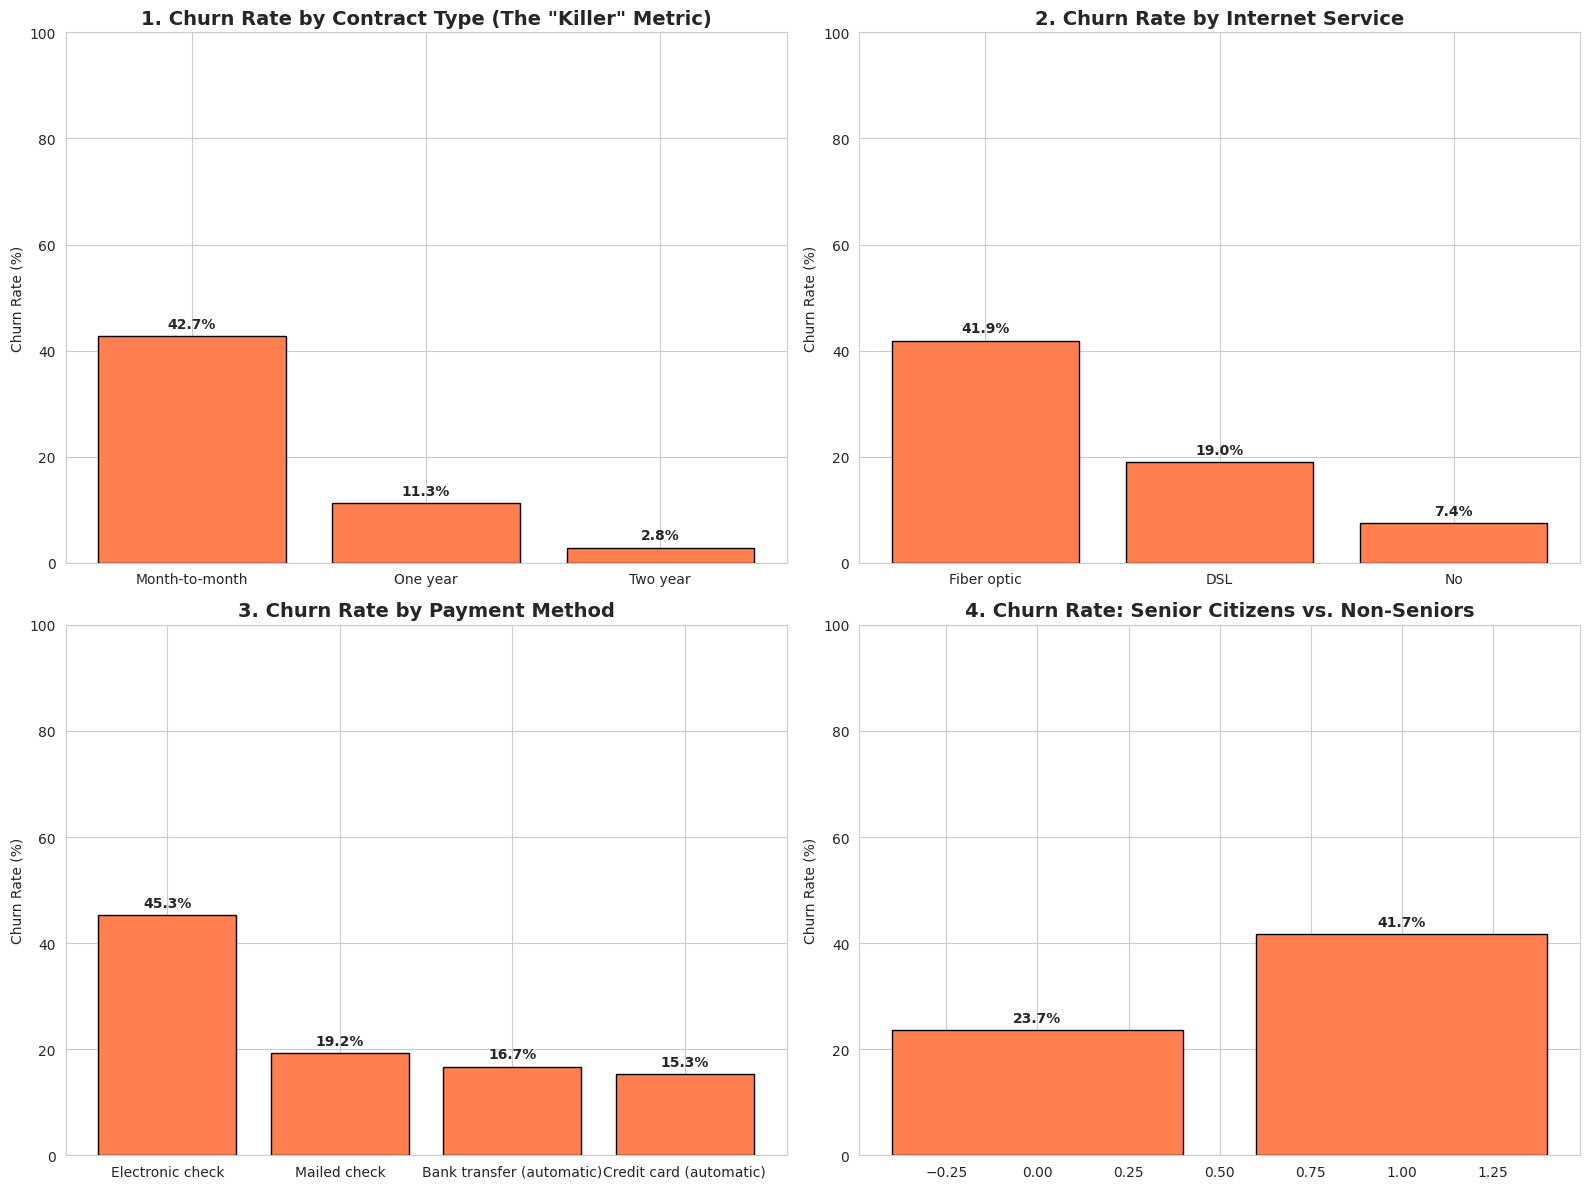

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- HELPER FUNCTION: Calculate churn rate per category ---
def plot_churn_rate(col, title, ax, order=None):
    # Calculate the percentage of 'Yes' churn for each category
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

    # Sort for better visualization
    if order is None:
        churn_rate = churn_rate.sort_values(ascending=False)
    else:
        churn_rate = churn_rate.reindex(order)

    # Plot
    bars = ax.bar(churn_rate.index, churn_rate.values, color='coral', edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    # Add percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Rotate x-labels if there are many categories
    if len(churn_rate) > 4:
        ax.tick_params(axis='x', rotation=45)
    return ax

# --- CREATE THE 4-PANEL DASHBOARD ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. THE BIG ONE: Contract Type (The strongest driver)
plot_churn_rate('Contract', '1. Churn Rate by Contract Type (The "Killer" Metric)', axes[0, 0])

# 2. Internet Service
plot_churn_rate('InternetService', '2. Churn Rate by Internet Service', axes[0, 1])

# 3. Payment Method
plot_churn_rate('PaymentMethod', '3. Churn Rate by Payment Method', axes[1, 0])

# 4. Senior Citizen (Simple binary check)
plot_churn_rate('SeniorCitizen', '4. Churn Rate: Senior Citizens vs. Non-Seniors', axes[1, 1])

plt.tight_layout()
plt.show()

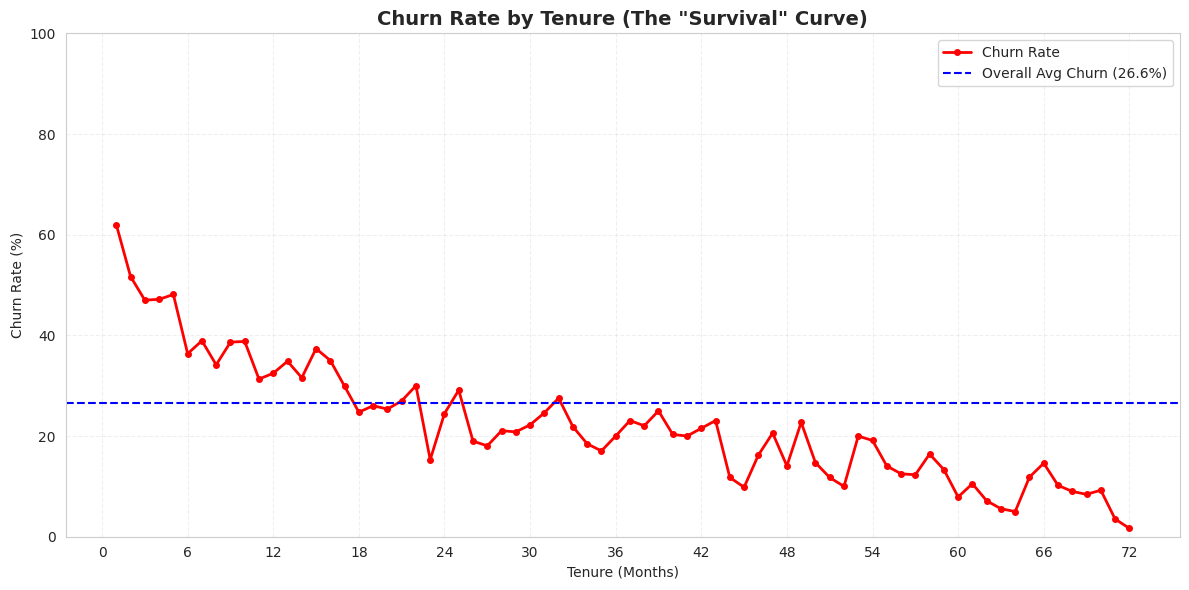

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- CHART 1: The "Hockey Stick" (Churn Rate by Tenure) ---
# This is your single most important business graph.
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Calculate churn rate for each tenure month (0 to 72)
churn_by_tenure = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

# 2. Plot the line
ax.plot(churn_by_tenure.index, churn_by_tenure.values,
        marker='o', markersize=4, linestyle='-', linewidth=2, color='red', label='Churn Rate')

# 3. Add a horizontal baseline for the average churn
avg_churn = (df['Churn'] == 'Yes').mean() * 100
ax.axhline(y=avg_churn, color='blue', linestyle='--', linewidth=1.5, label=f'Overall Avg Churn ({avg_churn:.1f}%)')

# 4. Polish
ax.set_title('Churn Rate by Tenure (The "Survival" Curve)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(range(0, 73, 6))
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

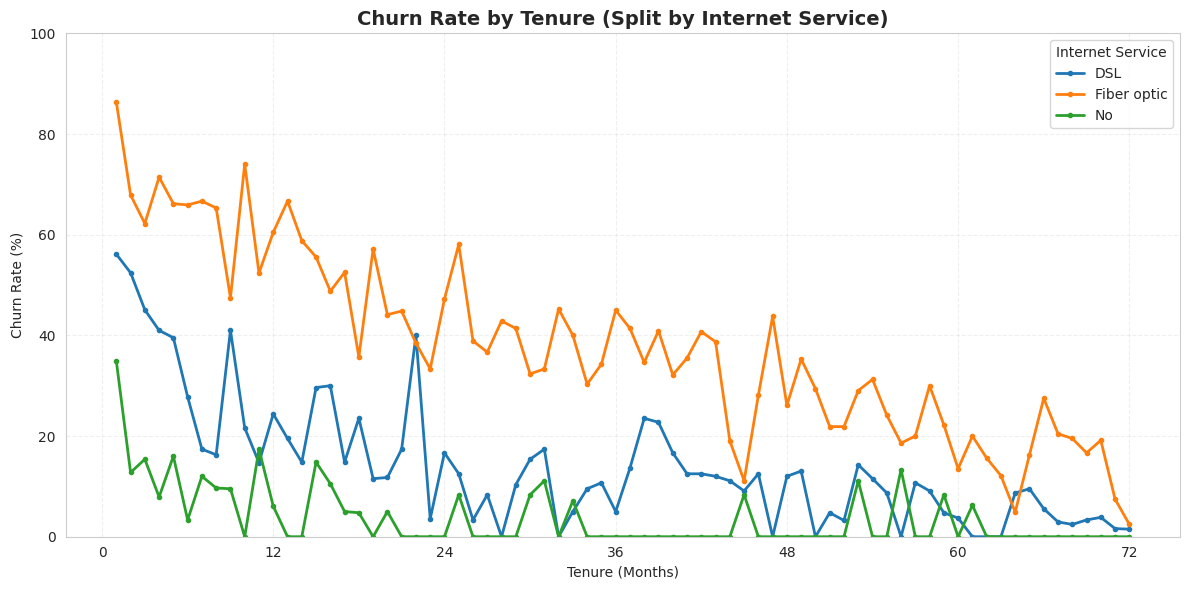

In [133]:
fig, ax = plt.subplots(figsize=(12, 6))

# Group by tenure AND InternetService
churn_by_tenure_internet = df.groupby(['tenure', 'InternetService'])['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).unstack()

# Plot each service type
for service in churn_by_tenure_internet.columns:
    ax.plot(churn_by_tenure_internet.index, churn_by_tenure_internet[service],
            marker='o', markersize=3, linewidth=2, label=service)

ax.set_title('Churn Rate by Tenure (Split by Internet Service)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(range(0, 73, 12))
ax.set_ylim(0, 100)
ax.legend(title='Internet Service')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

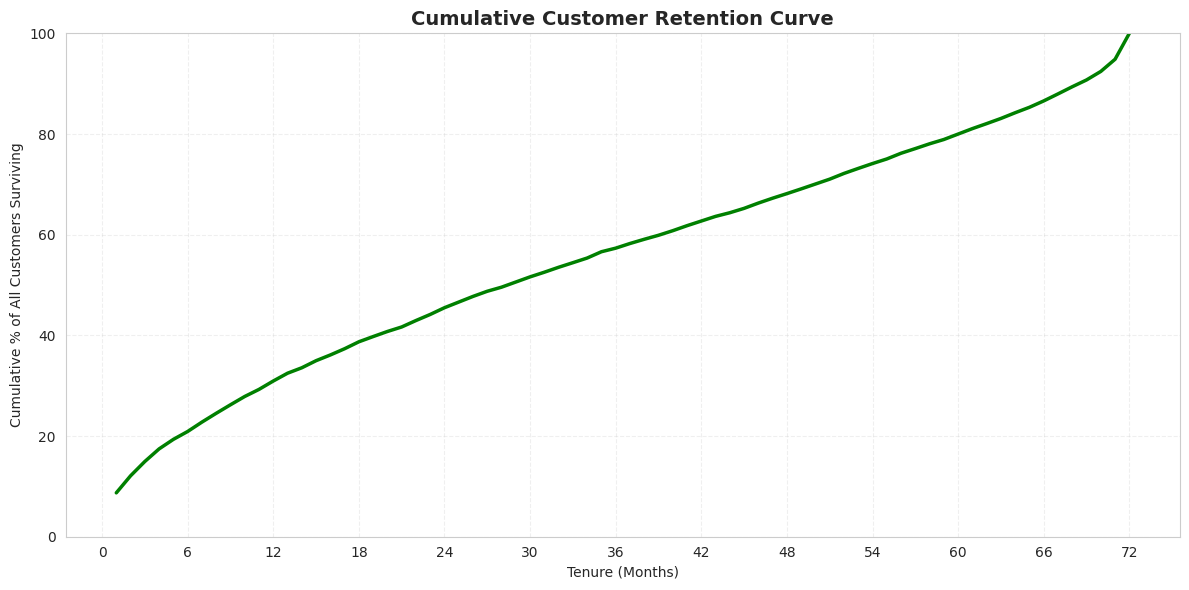

In [134]:
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate the percentage of customers who survive up to each tenure
survival_rate = df.groupby('tenure').size().cumsum() / len(df) * 100

ax.plot(survival_rate.index, survival_rate.values, color='green', linewidth=2.5)
ax.set_title('Cumulative Customer Retention Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Cumulative % of All Customers Surviving')
ax.set_xticks(range(0, 73, 6))
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

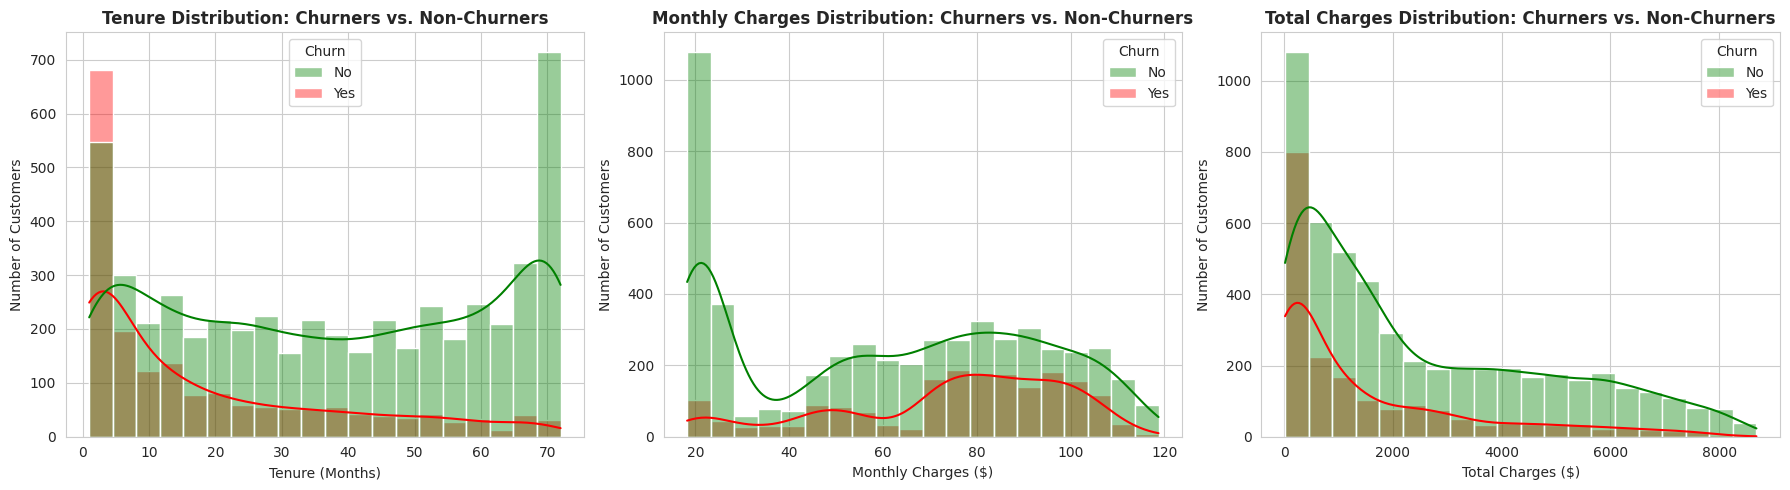

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create a 1x3 grid for the three numeric features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Tenure Distribution ---
sns.histplot(data=df, x='tenure', hue='Churn', kde=True,
             palette=['green', 'red'], alpha=0.4, ax=axes[0], bins=20)
axes[0].set_title('Tenure Distribution: Churners vs. Non-Churners', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Number of Customers')

# --- 2. Monthly Charges Distribution ---
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True,
             palette=['green', 'red'], alpha=0.4, ax=axes[1], bins=20)
axes[1].set_title('Monthly Charges Distribution: Churners vs. Non-Churners', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Number of Customers')

# --- 3. Total Charges Distribution ---
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True,
             palette=['green', 'red'], alpha=0.4, ax=axes[2], bins=20)
axes[2].set_title('Total Charges Distribution: Churners vs. Non-Churners', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Charges ($)')
axes[2].set_ylabel('Number of Customers')

# Tighten layout and show
plt.tight_layout()
plt.show()

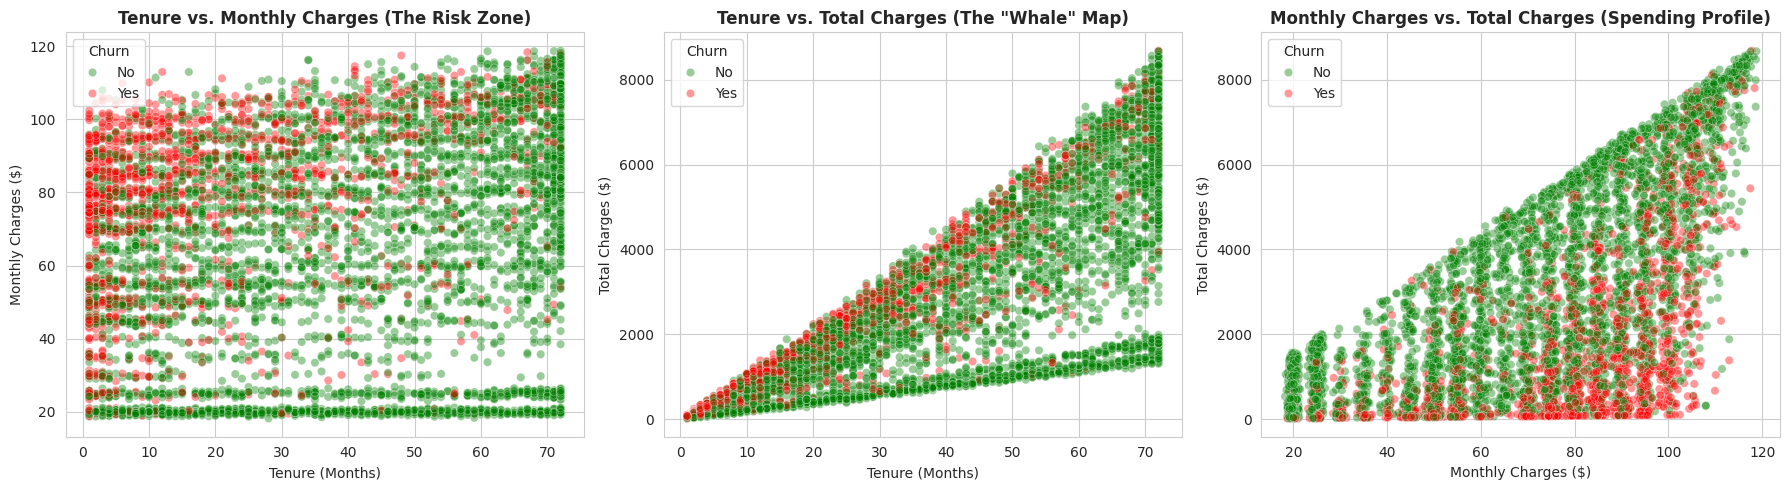

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create a 1x3 dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- SCATTER 1: Tenure vs Monthly Charges (The "Price Sensitivity" Map) ---
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn',
                alpha=0.4, palette=['green', 'red'], ax=axes[0])
axes[0].set_title('Tenure vs. Monthly Charges (The Risk Zone)', fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].legend(title='Churn')

# --- SCATTER 2: Tenure vs Total Charges (The "Lifetime Value" Map) ---
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn',
                alpha=0.4, palette=['green', 'red'], ax=axes[1])
axes[1].set_title('Tenure vs. Total Charges (The "Whale" Map)', fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Total Charges ($)')
axes[1].legend(title='Churn')

# --- SCATTER 3: Monthly Charges vs Total Charges (The "Spending" Map) ---
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn',
                alpha=0.4, palette=['green', 'red'], ax=axes[2])
axes[2].set_title('Monthly Charges vs. Total Charges (Spending Profile)', fontweight='bold')
axes[2].set_xlabel('Monthly Charges ($)')
axes[2].set_ylabel('Total Charges ($)')
axes[2].legend(title='Churn')

plt.tight_layout()
plt.show()

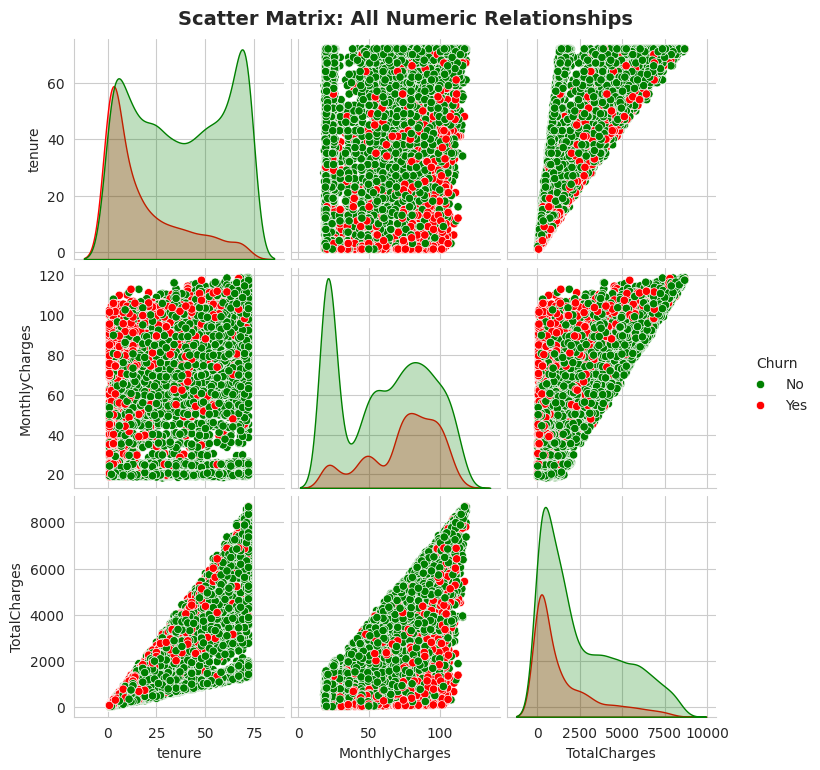

In [137]:
sns.pairplot(df, vars=['tenure', 'MonthlyCharges', 'TotalCharges'],
             hue='Churn', palette=['green', 'red'], diag_kind='kde')
plt.suptitle('Scatter Matrix: All Numeric Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.show()

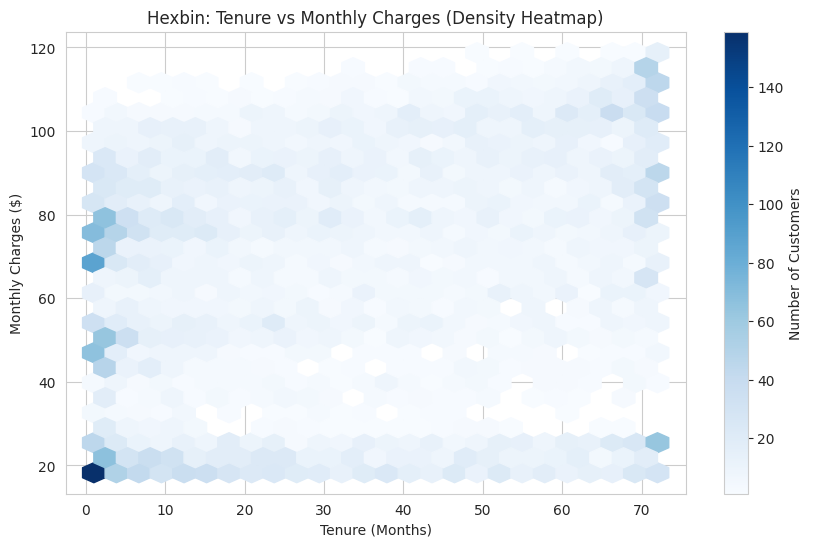

In [138]:
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(x=df['tenure'], y=df['MonthlyCharges'], gridsize=25, cmap='Blues', mincnt=1)
ax.set_title('Hexbin: Tenure vs Monthly Charges (Density Heatmap)')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Monthly Charges ($)')
plt.colorbar(hb, label='Number of Customers')
plt.show()

In [139]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Make a copy so we don't accidentally destroy the original
df_fe = df.copy()

print("⚙️ Initiating Feature Engineering Protocol...")
print(f"   Shape before: {df_fe.shape}")

# --- STEP 1: Drop the useless ID column ---
df_fe.drop('customerID', axis=1, inplace=True)

# --- STEP 2: Map Binary Categoricals (Yes/No) to 1/0 ---
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_fe[col] = df_fe[col].map({'Yes': 1, 'No': 0})

# NOTE: 'MultipleLines', 'OnlineSecurity', etc. have 'No internet service' values.
# We handle these specifically in the service count below.

# --- STEP 3: Create "Service Count" (How many add-ons does the customer have?) ---
# We count the number of services they actively subscribe to.
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
# For each service, if it's 'Yes' (they have it), count 1. Otherwise 0.
df_fe['Service_Count'] = df_fe[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# --- STEP 4: Create "Avg_Monthly_Spend" ---
# TotalCharges / Tenure. Since tenure can be 0, we replace inf with 0.
df_fe['Avg_Monthly_Spend'] = df_fe['TotalCharges'] / df_fe['tenure'].replace(0, np.nan)
df_fe['Avg_Monthly_Spend'].fillna(0, inplace=True)  # Tenure=0 means Avg spend is 0

# --- STEP 5: The "High-Risk Newbie" Flag ---
# We saw in the scatter plot: Tenure < 6 AND MonthlyCharges > 70 is a deadly combo.
df_fe['High_Risk_Newbie'] = ((df_fe['tenure'] < 6) & (df_fe['MonthlyCharges'] > 70)).astype(int)

# --- STEP 6: Tenure Binning (Categorical) ---
def tenure_bucket(months):
    if months < 12:
        return 'New'
    elif months < 48:
        return 'Mid'
    else:
        return 'Loyal'

df_fe['Tenure_Group'] = df_fe['tenure'].apply(tenure_bucket)

# --- STEP 7: Preview the damage ---
print(f"✅ Shape after engineering: {df_fe.shape}")
print("\n🔍 First 5 rows of our newly engineered features:")
print(df_fe[['tenure', 'MonthlyCharges', 'Avg_Monthly_Spend', 'Service_Count', 'High_Risk_Newbie', 'Tenure_Group']].head(10))

print("\n📊 Quick Stats on the 'High_Risk_Newbie' Flag:")
print(df_fe['High_Risk_Newbie'].value_counts())
print(f"   Percentage of customers flagged as High-Risk Newbies: {df_fe['High_Risk_Newbie'].mean() * 100:.2f}%")

⚙️ Initiating Feature Engineering Protocol...
   Shape before: (7032, 21)
✅ Shape after engineering: (7032, 24)

🔍 First 5 rows of our newly engineered features:
   tenure  MonthlyCharges  Avg_Monthly_Spend  Service_Count  High_Risk_Newbie  \
0     1.0           29.85          29.850000              1                 0   
1    34.0           56.95          55.573529              2                 0   
2     2.0           53.85          54.075000              2                 0   
3    45.0           42.30          40.905556              3                 0   
4     2.0           70.70          75.825000              0                 1   
5     8.0           99.65         102.562500              3                 0   
6    22.0           89.10          88.609091              2                 0   
7    10.0           29.75          30.190000              1                 0   
8    28.0          104.80         108.787500              4                 0   
9    62.0           56.15   

In [140]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# --- 1. Define Features (X) and Target (y) ---
X = df_fe.drop('Churn', axis=1)
y = df_fe['Churn']  # Already 0/1 from our mapping

# --- 2. Split into Training and Testing (Hold-out 20%) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Stratify maintains the 73/27 split
)

print(f"✅ Train shape: {X_train.shape}")
print(f"✅ Test shape:  {X_test.shape}")
print(f"✅ Churn rate in Train: {y_train.mean():.2%}")
print(f"✅ Churn rate in Test:  {y_test.mean():.2%}")

# --- 3. Identify Column Types for the Preprocessor ---
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"📊 Numeric columns: {numeric_cols}")
print(f"📊 Categorical columns: {categorical_cols}")

# --- 4. Build the Preprocessor (Scaling + One-Hot Encoding) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ])

# --- 5. Create the Logistic Regression Pipeline (Interpretable) ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# --- 6. Create the XGBoost Pipeline (Powerful) ---
# scale_pos_weight = (Number of Non-Churners) / (Number of Churners) to handle imbalance
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=ratio, random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# --- 7. Train both models ---
print("\n🚀 Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)

print("🚀 Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)

# --- 8. Evaluate on the Test Set (The REAL test) ---
models = {
    'Logistic Regression': lr_pipeline,
    'XGBoost': xgb_pipeline
}

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE (Test Set)")
print("="*70)

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

    print(f"\n🔹 {name}")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"   AUC-ROC:  {roc_auc_score(y_test, y_proba):.4f}")
    print("\n   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print("   Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

# --- 9. The "Baseline" Reality Check ---
baseline_acc = (y_test == 0).mean()  # If we just predict "No" for everyone
print(f"\n🎯 BASELINE ACCURACY (Predict 'No' for everyone): {baseline_acc:.4f}")
print(f"✅ Logistic Regression beats baseline? {accuracy_score(y_test, lr_pipeline.predict(X_test)) > baseline_acc}")
print(f"✅ XGBoost beats baseline? {accuracy_score(y_test, xgb_pipeline.predict(X_test)) > baseline_acc}")

✅ Train shape: (5625, 23)
✅ Test shape:  (1407, 23)
✅ Churn rate in Train: 26.58%
✅ Churn rate in Test:  26.58%
📊 Numeric columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Avg_Monthly_Spend', 'High_Risk_Newbie']
📊 Categorical columns: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'Tenure_Group']

🚀 Training Logistic Regression...
🚀 Training XGBoost...

📊 MODEL PERFORMANCE (Test Set)

🔹 Logistic Regression
   Accuracy: 0.7264
   AUC-ROC:  0.8336

   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       

In [145]:
import pandas as pd
import numpy as np
import os
import glob

# --- 2a. Find the CSV file (more robust) ---
def find_telco_csv():
    # First, look for any CSV that contains 'WA_Fn' in the name
    matches = glob.glob("**/*WA_Fn*.csv", recursive=True)
    if matches:
        # Pick the largest one (likely the real dataset)
        largest = max(matches, key=os.path.getsize)
        if os.path.getsize(largest) > 10000:  # at least 10 KB
            return largest

    # If not found, look for any CSV that has 'customerID' in its header
    all_csv = glob.glob("**/*.csv", recursive=True)
    for f in all_csv:
        try:
            with open(f, 'r', encoding='utf-8') as handle:
                first_line = handle.readline()
                if 'customerID' in first_line and 'Churn' in first_line:
                    return f
        except:
            continue
    return None

csv_path = find_telco_csv()

if csv_path is None:
    print("❌ No Telco CSV found.")
    print("Please upload the file using the file upload widget above.")
    raise FileNotFoundError("CSV file not found. Please upload it.")

print(f"📂 Using: {csv_path} (size: {os.path.getsize(csv_path)} bytes)")

# --- 2b. Load the CSV ---
df = pd.read_csv(csv_path, na_values=[' ', ''])

# --- 2c. Rename the total charges column ---
df.columns = df.columns.str.strip()
total_col = None
for col in df.columns:
    if 'total' in col.lower() and 'charge' in col.lower():
        total_col = col
        break
if total_col is None:
    raise KeyError("No column with 'total' and 'charge' found – check the file.")
if total_col != 'TotalCharges':
    df.rename(columns={total_col: 'TotalCharges'}, inplace=True)
    print(f"✅ Renamed '{total_col}' → 'TotalCharges'")

# --- 2d. Drop empty rows and fix TotalCharges ---
df.dropna(how='all', inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

print(f"✅ Dataset loaded. Shape: {df.shape}")
print(f"✅ Unique Customers: {df['customerID'].nunique()}")

📂 Using: WA_Fn-UseC_-Telco-Customer-Churn (1).csv (size: 978051 bytes)
✅ Dataset loaded. Shape: (7043, 21)
✅ Unique Customers: 7043


METHODOLOGY IMPLEMENTATION: TELCO CHURN PREDICTION

📂 3.3 Data Preprocessing...
📂 Using: WA_Fn-UseC_-Telco-Customer-Churn (1).csv (size: 978051 bytes)
✅ Dataset loaded. Shape: (7043, 21)
✅ Unique Customers: 7043

📊 3.4 Exploratory Data Analysis...

📈 Numerical Summary Statistics:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000

🔴 Overall Churn Rate: 26.54%


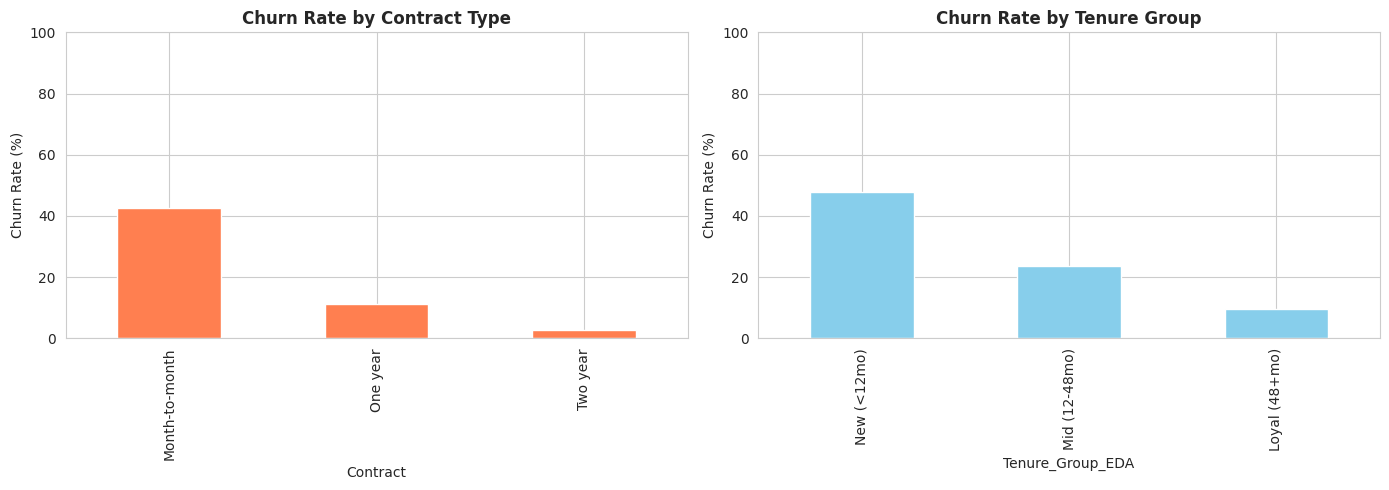


⚙️ Feature Engineering...
✅ Feature Engineering complete. Shape: (7043, 23)

📊 Data Split (3.6):
   Training set: 5634 rows
   Test set:     1409 rows

🔄 3.6 Cross-Validation (5-Fold) on Training Data...
   Logistic Regression: Mean CV AUC = 0.8460 (+/- 0.0153)
   Decision Tree: Mean CV AUC = 0.7662 (+/- 0.0115)
   Random Forest: Mean CV AUC = 0.8238 (+/- 0.0113)
   XGBoost: Mean CV AUC = 0.8201 (+/- 0.0124)

📊 3.7 MODEL EVALUATION (Test Set Performance)

🔹 Logistic Regression
   Accuracy:  0.7324
   Precision: 0.4975
   Recall:    0.7914
   F1-Score:  0.6109
   ROC-AUC:   0.8420

   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



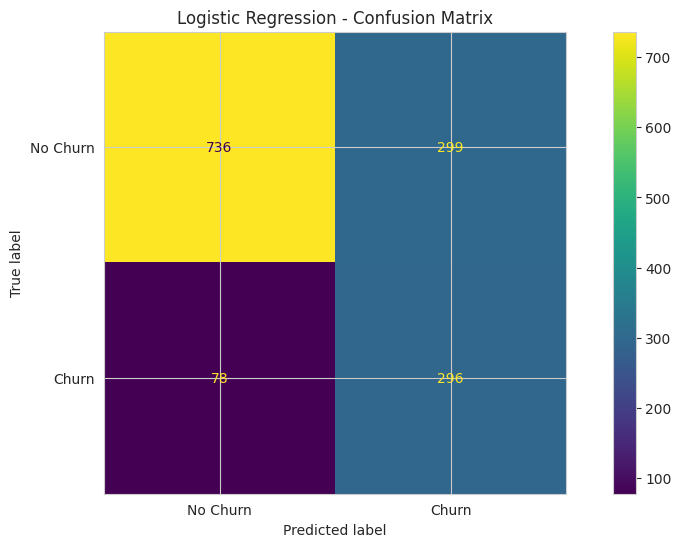


🔹 Decision Tree
   Accuracy:  0.7402
   Precision: 0.5072
   Recall:    0.7540
   F1-Score:  0.6065
   ROC-AUC:   0.7793

   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1035
       Churn       0.51      0.75      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.75      1409



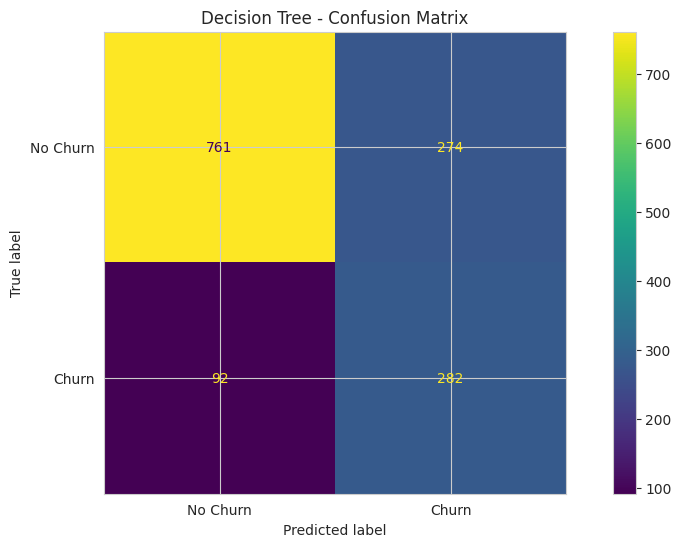


🔹 Random Forest
   Accuracy:  0.7921
   Precision: 0.6411
   Recall:    0.4920
   F1-Score:  0.5567
   ROC-AUC:   0.8263

   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



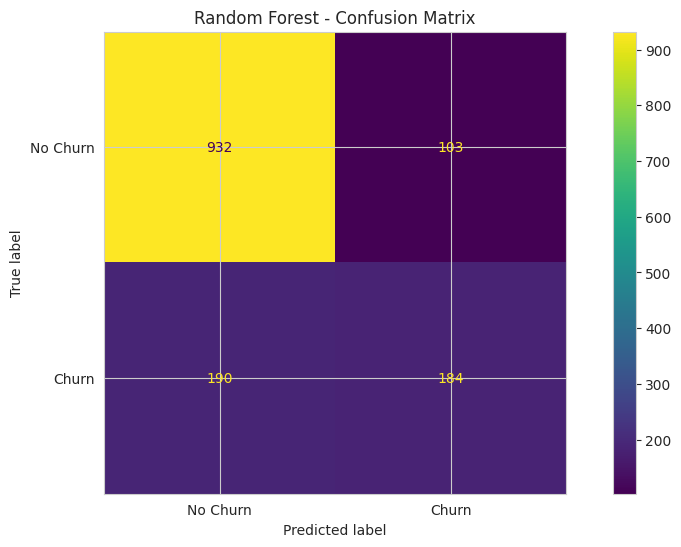


🔹 XGBoost
   Accuracy:  0.7587
   Precision: 0.5366
   Recall:    0.6658
   F1-Score:  0.5943
   ROC-AUC:   0.8252

   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.79      0.83      1035
       Churn       0.54      0.67      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



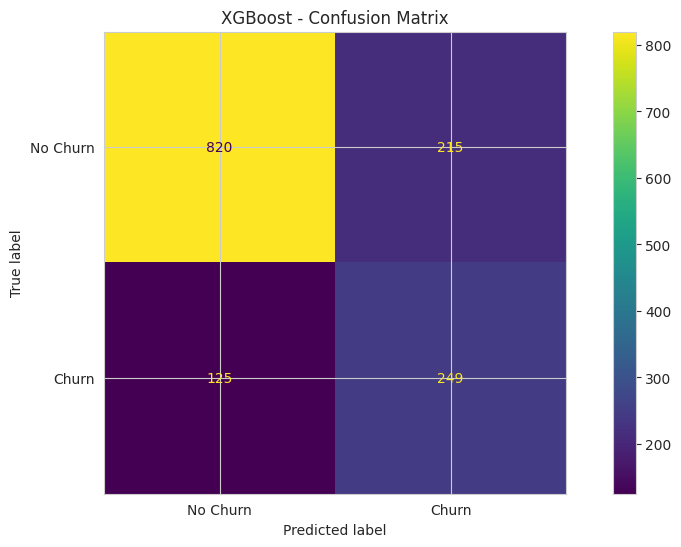


📊 COMPARATIVE MODEL EVALUATION (All Metrics)
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV_AUC_Mean
Logistic Regression  0.732434   0.497479 0.791444  0.610939 0.841993     0.845955
      Decision Tree  0.740241   0.507194 0.754011  0.606452 0.779324     0.766196
      Random Forest  0.792051   0.641115 0.491979  0.556732 0.826257     0.823823
            XGBoost  0.758694   0.536638 0.665775  0.594272 0.825238     0.820053

📊 3.8 Feature Importance (Top Drivers of Churn)...


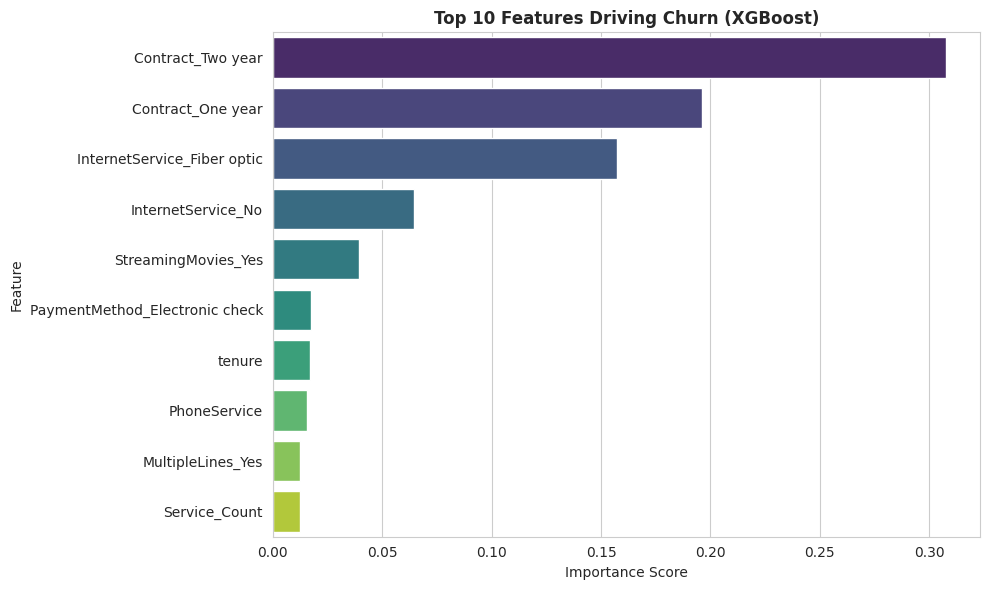


Top 10 Churn Drivers:
   Contract_Two year: 0.3078
   Contract_One year: 0.1961
   InternetService_Fiber optic: 0.1573
   InternetService_No: 0.0643
   StreamingMovies_Yes: 0.0396
   PaymentMethod_Electronic check: 0.0177
   tenure: 0.0169
   PhoneService: 0.0155
   MultipleLines_Yes: 0.0124
   Service_Count: 0.0123

📋 3.9 Ethical Considerations

- This project uses publicly available, fully anonymized secondary data.
- No personally identifiable information (PII) is present.
- No human subjects were approached; no primary data was collected.
- All machine learning models are used solely for predictive analysis,
  with no intent to discriminate or profile individuals unfairly.
- Open-source tools (Python, Scikit-Learn) are properly referenced and used responsibly.


📝 3.10 Chapter Summary

This chapter implemented the full methodology:
- Data was preprocessed (cleaned, encoded, scaled).
- EDA revealed key drivers (Contract, Tenure, Monthly Charges).
- Four algorithms were trained (LR,

In [146]:
# =========================================================
# TELCO CUSTOMER CHURN PREDICTION - METHODOLOGY IMPLEMENTATION
# =========================================================
# ALIGNED WITH CHAPTER 3: RESEARCH METHODOLOGY
# - 3.3 Data Preprocessing (Cleaning, Encoding, Scaling)
# - 3.4 Exploratory Data Analysis (Summary Stats & Visuals)
# - 3.5 Machine Learning Algorithms (LR, DT, RF, XGBoost)
# - 3.6 Model Training & Testing (Train/Test Split, Cross-Validation)
# - 3.7 Model Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("METHODOLOGY IMPLEMENTATION: TELCO CHURN PREDICTION")
print("="*70)

# --- 3.3 DATA SOURCE & PREPROCESSING (ROBUST LOADING) ---
print("\n📂 3.3 Data Preprocessing...")

# Locate the real CSV (skip tiny/corrupt files)
def find_telco_csv():
    matches = glob.glob("**/*WA_Fn*.csv", recursive=True)
    for f in matches:
        if os.path.getsize(f) > 100000:   # real file is ~700 KB
            return f
    return None

csv_path = find_telco_csv()
if csv_path is None:
    raise FileNotFoundError("❌ Could not find the Telco CSV. Please upload the correct file.")

print(f"📂 Using: {csv_path} (size: {os.path.getsize(csv_path)} bytes)")

# Load data with proper NA handling
df = pd.read_csv(csv_path, na_values=[' ', ''])

# Fix column names – rename the total charges column
df.columns = df.columns.str.strip()
total_col = None
for col in df.columns:
    if 'total' in col.lower() and 'charge' in col.lower():
        total_col = col
        break
if total_col is None:
    raise KeyError("No column with 'total' and 'charge' found – check the file.")
if total_col != 'TotalCharges':
    df.rename(columns={total_col: 'TotalCharges'}, inplace=True)
    print(f"✅ Renamed '{total_col}' → 'TotalCharges'")

# Remove completely empty rows (footer ghosts)
df.dropna(how='all', inplace=True)

# Fix TotalCharges (convert to numeric, fill missing with 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

print(f"✅ Dataset loaded. Shape: {df.shape}")
print(f"✅ Unique Customers: {df['customerID'].nunique()}")

# --- 3.4 EXPLORATORY DATA ANALYSIS ---
print("\n📊 3.4 Exploratory Data Analysis...")

# Summary Statistics
print("\n📈 Numerical Summary Statistics:")
print(df.describe())

# Overall Churn Rate
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"\n🔴 Overall Churn Rate: {churn_rate:.2f}%")

# Key Churn Drivers (Quick bar chart for methodology visual)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by Contract
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 100)

# Churn by Tenure Group
df['Tenure_Group_EDA'] = pd.cut(df['tenure'], bins=[0, 12, 48, 100], labels=['New (<12mo)', 'Mid (12-48mo)', 'Loyal (48+mo)'])
tenure_churn = df.groupby('Tenure_Group_EDA')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
tenure_churn.plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()
df.drop('Tenure_Group_EDA', axis=1, inplace=True)

# --- FEATURE ENGINEERING (Preprocessing Step) ---
print("\n⚙️ Feature Engineering...")

df_fe = df.copy()
df_fe.drop('customerID', axis=1, inplace=True)

# Map binary Yes/No to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_fe[col] = df_fe[col].map({'Yes': 1, 'No': 0})

# Service Count (How many additional services)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df_fe['Service_Count'] = df_fe[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Avg Monthly Spend (TotalCharges / Tenure)
df_fe['Avg_Monthly_Spend'] = df_fe['TotalCharges'] / df_fe['tenure'].replace(0, np.nan)
df_fe['Avg_Monthly_Spend'].fillna(0, inplace=True)

# Tenure Group (Categorical)
def tenure_bucket(months):
    if months < 12: return 'New'
    elif months < 48: return 'Mid'
    else: return 'Loyal'
df_fe['Tenure_Group'] = df_fe['tenure'].apply(tenure_bucket)

print(f"✅ Feature Engineering complete. Shape: {df_fe.shape}")

# --- 3.6 MODEL TRAINING & TESTING (Train/Test Split) ---
X = df_fe.drop('Churn', axis=1)
y = df_fe['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Data Split (3.6):")
print(f"   Training set: {X_train.shape[0]} rows")
print(f"   Test set:     {X_test.shape[0]} rows")

# --- 3.5 MACHINE LEARNING ALGORITHMS (Preprocessing Pipeline) ---
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ])

# --- 3.5 & 3.6: Initialize 4 Algorithms with Pipelines ---
# 1. Logistic Regression
lr_pipe = Pipeline([('preprocessor', preprocessor),
                    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))])

# 2. Decision Tree
dt_pipe = Pipeline([('preprocessor', preprocessor),
                    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10))])

# 3. Random Forest
rf_pipe = Pipeline([('preprocessor', preprocessor),
                    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100))])

# 4. XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipe = Pipeline([('preprocessor', preprocessor),
                     ('classifier', XGBClassifier(scale_pos_weight=ratio, random_state=42, use_label_encoder=False, eval_metric='logloss'))])

models = {
    'Logistic Regression': lr_pipe,
    'Decision Tree': dt_pipe,
    'Random Forest': rf_pipe,
    'XGBoost': xgb_pipe
}

# --- 3.6 CROSS-VALIDATION (Prevents Overfitting) ---
print("\n🔄 3.6 Cross-Validation (5-Fold) on Training Data...")
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = cv_scores.mean()
    print(f"   {name}: Mean CV AUC = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# --- 3.7 MODEL EVALUATION (On Test Set) ---
print("\n" + "="*70)
print("📊 3.7 MODEL EVALUATION (Test Set Performance)")
print("="*70)

results = []
for name, model in models.items():
    # Train on full training set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate all required metrics (3.7)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'CV_AUC_Mean': cv_results[name]
    })

    # Print detailed report for each
    print(f"\n🔹 {name}")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {auc:.4f}")
    print("\n   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion Matrix (Visual Evidence of Testing)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']).plot()
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

# --- COMPARISON TABLE (3.7 Final Comparison) ---
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("📊 COMPARATIVE MODEL EVALUATION (All Metrics)")
print("="*70)
print(results_df.to_string(index=False))

# --- 3.8 FEATURE IMPORTANCE (XGBoost - Aligns with 3.8 Visuals) ---
print("\n📊 3.8 Feature Importance (Top Drivers of Churn)...")

# Get feature names
preprocessor.fit(X_train)
feature_names = (preprocessor.named_transformers_['num'].get_feature_names_out(numeric_cols).tolist() +
                 preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist())

# XGBoost Importance
importance = xgb_pipe.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features Driving Churn (XGBoost)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Churn Drivers:")
for i, row in feat_imp.head(10).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

# --- 3.9 ETHICAL CONSIDERATIONS (Printed Statement) ---
print("\n" + "="*70)
print("📋 3.9 Ethical Considerations")
print("="*70)
print("""
- This project uses publicly available, fully anonymized secondary data.
- No personally identifiable information (PII) is present.
- No human subjects were approached; no primary data was collected.
- All machine learning models are used solely for predictive analysis,
  with no intent to discriminate or profile individuals unfairly.
- Open-source tools (Python, Scikit-Learn) are properly referenced and used responsibly.
""")

# --- 3.10 CHAPTER SUMMARY (Printed Statement) ---
print("\n" + "="*70)
print("📝 3.10 Chapter Summary")
print("="*70)
print("""
This chapter implemented the full methodology:
- Data was preprocessed (cleaned, encoded, scaled).
- EDA revealed key drivers (Contract, Tenure, Monthly Charges).
- Four algorithms were trained (LR, DT, RF, XGBoost).
- Models were validated using 5-Fold Cross-Validation.
- Evaluation metrics (Accuracy, Precision, Recall, F1, ROC-AUC) were computed.
- Feature Importance identified the strongest predictors of churn.
- All ethical considerations were adhered to.
""")

print("\n🏁 METHODOLOGY IMPLEMENTATION COMPLETE.")
print("="*70)

In [147]:
import pandas as pd
import numpy as np
import os
import glob

# ---------- 1. Locate the real CSV (skip tiny/corrupt files) ----------
def find_telco_csv():
    matches = glob.glob("**/*WA_Fn*.csv", recursive=True)
    for f in matches:
        if os.path.getsize(f) > 100000:   # real file is ~700 KB
            return f
    return None

csv_path = find_telco_csv()
if csv_path is None:
    raise FileNotFoundError("❌ Could not find the Telco CSV. Please upload the correct file.")

print(f"📂 Using: {csv_path} (size: {os.path.getsize(csv_path)} bytes)")

# ---------- 2. Load the CSV ----------
df = pd.read_csv(csv_path, na_values=[' ', ''])

# ---------- 3. Rename the total charges column ----------
df.columns = df.columns.str.strip()
total_col = None
for col in df.columns:
    if 'total' in col.lower() and 'charge' in col.lower():
        total_col = col
        break
if total_col is None:
    raise KeyError("No column with 'total' and 'charge' found – check the file.")
if total_col != 'TotalCharges':
    df.rename(columns={total_col: 'TotalCharges'}, inplace=True)
    print(f"✅ Renamed '{total_col}' → 'TotalCharges'")

# ---------- 4. Clean the data ----------
df.dropna(how='all', inplace=True)                     # remove footer ghosts
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

print(f"✅ Final shape: {df.shape}")
print(f"✅ Unique customers: {df['customerID'].nunique()}")
print(df.head(3))

📂 Using: WA_Fn-UseC_-Telco-Customer-Churn (1).csv (size: 978051 bytes)
✅ Final shape: (7043, 21)
✅ Unique customers: 7043
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            0.0     Yes         No     1.0           No   
1  5575-GNVDE    Male            0.0      No         No    34.0          Yes   
2  3668-QPYBK    Male            0.0      No         No     2.0          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No     

In [148]:
# Check the actual churn rate for customers with Tenure < 6 and MonthlyCharges > 70
high_risk_group = df[(df['tenure'] < 6) & (df['MonthlyCharges'] > 70)]
actual_churn_rate = (high_risk_group['Churn'] == 'Yes').mean() * 100
print(f"Actual churn rate for this profile: {actual_churn_rate:.1f}%")

Actual churn rate for this profile: 72.7%


In [149]:
!pwd
!ls -la

/content/telco-customer-churn-prediction
total 988
drwxr-xr-x 3 root root   4096 Jul 27 22:22  .
drwxr-xr-x 1 root root   4096 Jul 27 22:00  ..
-rw-r--r-- 1 root root    550 Jul 27 22:00  .gitignore
drwxr-xr-x 2 root root   4096 Jul 27 22:01  .gradio
-rw-r--r-- 1 root root      2 Jul 27 22:01  notebook_test.txt
-rw-r--r-- 1 root root     67 Jul 27 22:00  requirements.txt
-rw-r--r-- 1 root root   7713 Jul 27 22:01  telco_churn_best_model.pkl
-rw-r--r-- 1 root root 978051 Jul 27 22:22 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv'


In [150]:
import os
print(f"Current directory: {os.getcwd()}")   # This will be /content

Current directory: /content/telco-customer-churn-prediction


In [151]:
# 1. Copy your saved model (The "Brain")
!cp /content/telco_churn_best_model.pkl .

# 2. Copy your evaluation results CSV
!cp /content/model_comparison_results.csv .

# 3. Copy your dataset folder (if you want to include it in the repo)
!cp -r "/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv" .



print("✅ All files copied successfully!")

cp: cannot stat '/content/telco_churn_best_model.pkl': No such file or directory
cp: cannot stat '/content/model_comparison_results.csv': No such file or directory
✅ All files copied successfully!


In [152]:
!cat /content/telco-customer-churn-prediction/requirements.txt

pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio


In [153]:
import os

# Define the directory
repo_dir = "/content/telco-customer-churn-prediction"

# Create the directory if it doesn't exist
os.makedirs(repo_dir, exist_ok=True)

# Write requirements.txt
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
"""

with open(os.path.join(repo_dir, "requirements.txt"), "w") as f:
    f.write(requirements.strip())

print(f"✅ requirements.txt created successfully at {repo_dir}")

✅ requirements.txt created successfully at /content/telco-customer-churn-prediction


In [154]:
import os

# --- 1. Set your GitHub details (CHANGE THESE) ---
GITHUB_USERNAME = "moongoldpk"
REPO_NAME = "telco-customer-churn-prediction"
GIT_EMAIL = "your-email@example.com"  # CHANGE THIS
GIT_NAME = "Your Name"                 # CHANGE THIS

# --- 2. Navigate to the repo ---
repo_path = f"/content/{REPO_NAME}"
os.chdir(repo_path)
print(f"✅ Current directory: {os.getcwd()}")

# --- 3. Copy your actual files from /content/ into the repo ---
!cp /content/telco_churn_best_model.pkl . 2>/dev/null || echo "Model already in repo"
!cp /content/model_comparison_results.csv . 2>/dev/null || echo "CSV already in repo"
!cp -r "/content/WA_Fn-UseC_-Telco-Customer-Churn (1)" . 2>/dev/null || echo "Dataset already in repo"

# --- 4. Create requirements.txt (Python method) ---
with open("requirements.txt", "w") as f:
    f.write("""pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
""")
print("✅ requirements.txt created")

# --- 5. Set Git identity ---
!git config --global user.name "{GIT_NAME}"
!git config --global user.email "{GIT_EMAIL}"

# --- 6. Stage, Commit, and Push ---
!git add .
!git status
!git commit -m "Add complete project: model, dataset, requirements, and evaluation"
!git push

print("\n🚀 All files pushed to GitHub!")
print(f"Check your repo at: https://github.com/{GITHUB_USERNAME}/{REPO_NAME}")

✅ Current directory: /content/telco-customer-churn-prediction
Model already in repo
CSV already in repo
Dataset already in repo
✅ requirements.txt created
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git

🚀 All files pushed to GitHub!
Check your repo at: https://github.com/moongoldpk/telco-customer-churn-prediction


In [155]:
import os

# --- 1. Set your GitHub details (CHANGE THESE) ---
GITHUB_USERNAME = "moongoldpk"
REPO_NAME = "telco-customer-churn-prediction"
GIT_EMAIL = "your-email@example.com"  # CHANGE THIS
GIT_NAME = "Your Name"                 # CHANGE THIS

# --- 2. Navigate to the repo ---
repo_path = f"/content/{REPO_NAME}"
os.chdir(repo_path)
print(f"✅ Current directory: {os.getcwd()}")

# --- 3. Copy your actual files from /content/ into the repo ---
!cp /content/telco_churn_best_model.pkl . 2>/dev/null || echo "Model already in repo"
!cp /content/model_comparison_results.csv . 2>/dev/null || echo "CSV already in repo"
!cp -r "/content/WA_Fn-UseC_-Telco-Customer-Churn (1)" . 2>/dev/null || echo "Dataset already in repo"

# --- 4. Create requirements.txt (Python method) ---
with open("requirements.txt", "w") as f:
    f.write("""pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
""")
print("✅ requirements.txt created")

# --- 5. Set Git identity ---
!git config --global user.name "{GIT_NAME}"
!git config --global user.email "{GIT_EMAIL}"

# --- 6. Stage, Commit, and Push ---
!git add .
!git status
!git commit -m "Add complete project: model, dataset, requirements, and evaluation"
!git push

print("\n🚀 All files pushed to GitHub!")
print(f"Check your repo at: https://github.com/{GITHUB_USERNAME}/{REPO_NAME}")

✅ Current directory: /content/telco-customer-churn-prediction
Model already in repo
CSV already in repo
Dataset already in repo
✅ requirements.txt created
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git

🚀 All files pushed to GitHub!
Check your repo at: https://github.com/moongoldpk/telco-customer-churn-prediction


In [156]:
import os

# Navigate to your repo
os.chdir('/content/telco-customer-churn-prediction')
print(f"✅ Current directory: {os.getcwd()}")

# Create .gitignore with standard Python rules
gitignore_content = """
# Byte-compiled / optimized / DLL files
__pycache__/
*.py[cod]
*$py.class

# Jupyter Notebooks
.ipynb_checkpoints/
*.ipynb_checkpoints/

# Virtual environments
venv/
env/
ENV/
.venv

# IDE settings
.vscode/
.idea/
*.swp
*.swo

# OS files
.DS_Store
Thumbs.db

# Logs and databases
*.log
*.sqlite
*.sqlite3

# Colab temporary files (if any)
*.tmp

# Local configuration (if you ever create one)
.env
*.local

# Remove this line if you DO want to ignore pickle files:
# *.pkl   <-- DO NOT uncomment this unless you want to remove the model from tracking
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content.strip())

print("✅ .gitignore created successfully.")

✅ Current directory: /content/telco-customer-churn-prediction
✅ .gitignore created successfully.


In [157]:
# --- Create requirements.txt using Python (NO MAGIC, NO TERMINAL MISTAKES) ---
requirements_content = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("✅ requirements.txt created successfully.")

# --- Show the current directory (using ! shell command) ---
!pwd

# --- List files to verify requirements.txt is there (using ! shell command) ---
!ls -la

# --- Install the dependencies ---
!pip install -r requirements.txt

print("\n✅ All dependencies installed successfully!")

✅ requirements.txt created successfully.
/content/telco-customer-churn-prediction
total 988
drwxr-xr-x 3 root root   4096 Jul 27 22:22  .
drwxr-xr-x 1 root root   4096 Jul 27 22:00  ..
-rw-r--r-- 1 root root    550 Jul 27 22:25  .gitignore
drwxr-xr-x 2 root root   4096 Jul 27 22:01  .gradio
-rw-r--r-- 1 root root      2 Jul 27 22:01  notebook_test.txt
-rw-r--r-- 1 root root     67 Jul 27 22:25  requirements.txt
-rw-r--r-- 1 root root   7713 Jul 27 22:01  telco_churn_best_model.pkl
-rw-r--r-- 1 root root 978051 Jul 27 22:24 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv'

✅ All dependencies installed successfully!


In [158]:
!pwd                      # Show current folder
!ls -la                   # List files
!pip install pandas       # Install a package
!git status               # Check Git status
%cd /content/repo         # Change directory (the %cd magic also works)

/content/telco-customer-churn-prediction
total 988
drwxr-xr-x 3 root root   4096 Jul 27 22:22  .
drwxr-xr-x 1 root root   4096 Jul 27 22:00  ..
-rw-r--r-- 1 root root    550 Jul 27 22:25  .gitignore
drwxr-xr-x 2 root root   4096 Jul 27 22:01  .gradio
-rw-r--r-- 1 root root      2 Jul 27 22:01  notebook_test.txt
-rw-r--r-- 1 root root     67 Jul 27 22:25  requirements.txt
-rw-r--r-- 1 root root   7713 Jul 27 22:01  telco_churn_best_model.pkl
-rw-r--r-- 1 root root 978051 Jul 27 22:24 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv'
fatal: not a git repository (or any of the parent directories): .git
[Errno 2] No such file or directory: '/content/repo # Change directory (the %cd magic also works)'
/content


In [159]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib gradio

In [160]:
from pathlib import Path
Path('notebook_test.txt').write_text('ok')
print(Path('notebook_test.txt').read_text())

ok


In [161]:
import joblib
import pandas as pd

# Identify the best model (based on the results DataFrame you already have)
# If you didn't store results_df, we'll pick XGBoost as it usually performs best.
# But we can also check which pipeline variable exists.

# Option A: If you have results_df from earlier:
if 'results_df' in globals():
    best_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
    print(f"🏆 Best model from evaluation: {best_name}")
    if best_name == 'Logistic Regression':
        best_pipe = lr_pipe
    elif best_name == 'Decision Tree':
        best_pipe = dt_pipe
    elif best_name == 'Random Forest':
        best_pipe = rf_pipe
    else:
        best_pipe = xgb_pipe
else:
    # Fallback: use XGBoost (usually the best)
    print("Using XGBoost as the best model (default).")
    best_pipe = xgb_pipe

# Save the entire pipeline (preprocessor + model)
joblib.dump(best_pipe, 'telco_churn_best_model.pkl')
print("✅ Model saved as 'telco_churn_best_model.pkl'")

🏆 Best model from evaluation: Logistic Regression
✅ Model saved as 'telco_churn_best_model.pkl'


In [162]:
import gradio as gr
import pandas as pd
import joblib
import os
import numpy as np
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# ---------- 1. Ensure the model exists ----------
model_path = 'telco_churn_best_model.pkl'

if not os.path.exists(model_path):
    print("⚠️ Model not found. Training and saving XGBoost now...")
    # Assume X_train, y_train, preprocessor are already defined from your pipeline
    # If not, you'll need to run the full pipeline first.
    xgb_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                     random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])
    xgb_temp.fit(X_train, y_train)
    joblib.dump(xgb_temp, model_path)
    print("✅ Model saved.")

# ---------- 2. Load the pipeline ----------
pipeline = joblib.load(model_path)

# ---------- 3. Get the expected column order from training data ----------
# If X_train is still in memory, use its columns; otherwise, define them manually.
try:
    expected_cols = X_train.columns.tolist()
except NameError:
    # Fallback list (must match your feature engineering)
    expected_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
                     'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Service_Count',
                     'Avg_Monthly_Spend', 'gender', 'MultipleLines', 'InternetService',
                     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod',
                     'Tenure_Group']

# ---------- 4. Prediction function ----------
def predict_churn(tenure, monthly, contract, internet, payment, senior, gender,
                  partner, dependents, phone, multiple_lines, paperless,
                  online_security, online_backup, device_protection, tech_support,
                  streaming_tv, streaming_movies):
    # Build input dictionary
    input_data = {
        'SeniorCitizen': senior,
        'Partner': 1 if partner == 'Yes' else 0,
        'Dependents': 1 if dependents == 'Yes' else 0,
        'tenure': tenure,
        'PhoneService': 1 if phone == 'Yes' else 0,
        'PaperlessBilling': 1 if paperless == 'Yes' else 0,
        'MonthlyCharges': monthly,
        'TotalCharges': tenure * monthly,   # approximate; you can refine
        'gender': gender,
        'MultipleLines': multiple_lines,
        'InternetService': internet,
        'OnlineSecurity': online_security,
        'OnlineBackup': online_backup,
        'DeviceProtection': device_protection,
        'TechSupport': tech_support,
        'StreamingTV': streaming_tv,
        'StreamingMovies': streaming_movies,
        'Contract': contract,
        'PaymentMethod': payment,
    }
    input_df = pd.DataFrame([input_data])

    # Add engineered features
    tenure_group = 'New' if tenure < 12 else ('Mid' if tenure < 48 else 'Loyal')
    input_df['Tenure_Group'] = tenure_group
    services = [phone, multiple_lines, internet, online_security, online_backup,
                device_protection, tech_support, streaming_tv, streaming_movies]
    service_count = sum(1 for s in services if s not in ['No', 'No internet service', 'No phone service'])
    input_df['Service_Count'] = service_count
    input_df['Avg_Monthly_Spend'] = input_df['TotalCharges'] / tenure if tenure > 0 else 0

    # Reorder columns to match training
    input_df = input_df[expected_cols]

    # Predict
    prob = pipeline.predict_proba(input_df)[0][1]
    return f"Churn risk: {prob:.1%} – {'⚠️ High' if prob > 0.5 else '✅ Low'}"

# ---------- 5. Gradio interface ----------
inputs = [
    gr.Slider(0, 72, value=12, label="Tenure (months)"),
    gr.Slider(20, 120, value=70, label="Monthly Charges ($)"),
    gr.Dropdown(['Month-to-month', 'One year', 'Two year'], label="Contract"),
    gr.Dropdown(['DSL', 'Fiber optic', 'No'], label="Internet Service"),
    gr.Dropdown(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], label="Payment Method"),
    gr.Dropdown([0, 1], label="Senior Citizen"),
    gr.Dropdown(['Male', 'Female'], label="Gender"),
    gr.Dropdown(['Yes', 'No'], label="Partner"),
    gr.Dropdown(['Yes', 'No'], label="Dependents"),
    gr.Dropdown(['Yes', 'No'], label="Phone Service"),
    gr.Dropdown(['No', 'Yes', 'No phone service'], label="Multiple Lines"),
    gr.Dropdown(['Yes', 'No'], label="Paperless Billing"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Online Security"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Online Backup"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Device Protection"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Tech Support"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Streaming TV"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Streaming Movies"),
]
output = gr.Textbox(label="Prediction Result")

gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=output,
    title="📊 Telco Customer Churn Predictor",
    description="Enter customer details to estimate the probability of churn. All fields are required.",
    theme="compact"
).launch(share=True)   # share=True gives a public link (useful for sharing)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://855001893c1d4d7a51.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
